# ANÁLISIS COMPLETO FINGER TAPPING — MDS-UPDRS 3.4
## Pipeline: Extracción → Inferencial → Discriminabilidad

**Estructura del pipeline:**
1. Extracción de features (misma lógica del notebook baseline, ahora para todos los scores)
2. Consolidación del dataset con etiquetas de score y sujeto
3. Análisis descriptivo por score
4. Análisis inferencial (Kruskal-Wallis + tamaños de efecto)
5. Análisis de discriminabilidad (LDA + LOSO + AUC/ROC)
6. Exportación de resultados

**Diseño del estudio:**
- Score 0: 23 personas sanas (15 × 6 pruebas + 8 × 4 pruebas = 122 pruebas)
- Scores 1–4: 3 sujetos simulando cada nivel, 10 pruebas c/u (30 pruebas por score)
- Manos: derecha e izquierda (archivos separados por nombre)
- Tarea: Finger Tapping MDS-UPDRS ítem 3.4

**Convención de nombres de archivo esperada:**
```
score0/GA_01_right_01.json  → Score 0, sujeto GA_01, mano derecha, prueba 1
score1/P01_left_03.json     → Score 1, sujeto P01, mano izquierda, prueba 3
```
El score se infiere de la carpeta. El sujeto, mano y prueba del nombre del archivo.

---
## CELDA 1 — Imports y configuración

In [1]:
"""
============================================================================
IMPORTS Y CONFIGURACIÓN GLOBAL
============================================================================
"""

import json
import os
import re
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy.signal import butter, filtfilt, find_peaks
from scipy.fft import fft, fftfreq
from scipy.interpolate import interp1d
from scipy.stats import kruskal, mannwhitneyu

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, ConfusionMatrixDisplay, accuracy_score,
    matthews_corrcoef
)
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# ─────────────────────────────────────────────
# CONFIGURACIÓN — ajustar rutas aquí
# ─────────────────────────────────────────────
class Config:
    # Raíz del dataset: debe contener subcarpetas score0/, score1/, ..., score4/
    # Cada subcarpeta con archivos .json de las pruebas
    RUTA_DATOS = "./FINGER_TAPPING"  # <── AJUSTAR
    
    # Carpeta de salida para todos los resultados
    RUTA_SALIDA = "./resultados_golpeteo_completo"
    
    # ── Señal ──
    FS = 100           # Hz objetivo
    FS_TOLERANCE = 0.20
    
    # ── Filtros ──
    GYRO_LOWCUT  = 0.5   # Hz
    GYRO_HIGHCUT = 8.0   # Hz
    ACCEL_CUTOFF = 5.0   # Hz
    
    # ── Detección de taps ──
    PICO_PROMINENCE_FACTOR = 0.1
    PICO_HEIGHT_FACTOR_POS = 0.1
    PICO_HEIGHT_FACTOR_NEG = 0.1
    PICO_MIN_DISTANCE = 10   # muestras (100 ms a 100 Hz)
    PICO_WIDTH        = 4
    N_CICLOS_ESPERADOS = 10
    USAR_TOP_N        = True
    UMBRAL_HESITACION = 1.5
    
    # ── Validación ──
    CICLOS_MIN_VALIDOS = 6   # mínimo de taps para considerar prueba válida
    DURACION_MINIMA    = 3.0 # segundos
    
    # ── Scores presentes en el dataset ──
    SCORES = [0, 1, 2, 3, 4]
    
    # ── Features para análisis (subset más discriminativo) ──
    FEATURES_ANALISIS = [
        'frecuencia', 'cadencia',
        'amplitud_media', 'amplitud_cv', 'amplitud_max',
        'amplitud_angular_media',
        'iti_media', 'iti_cv', 'iti_std',
        'regularidad', 'regularidad_ritmica',
        'decremento_pct', 'decremento_pendiente',
        'n_hesitaciones',
        'jerk_rms', 'jerk_rms_angular',
        'rms_acc_lateral', 'energia_relativa_dom',
        'velocidad_pico_media', 'compensacion_lateral'
    ]

os.makedirs(Config.RUTA_SALIDA, exist_ok=True)
os.makedirs(f"{Config.RUTA_SALIDA}/figuras", exist_ok=True)
os.makedirs(f"{Config.RUTA_SALIDA}/tablas", exist_ok=True)

print("✅ Configuración cargada")
print(f"   Ruta datos : {Config.RUTA_DATOS}")


✅ Configuración cargada
   Ruta datos : ./FINGER_TAPPING


---
## CELDA 2 — Funciones de procesamiento de señal (motor de extracción)

In [2]:
"""
============================================================================
MOTOR DE PROCESAMIENTO IMU → FEATURES
Idéntico al notebook baseline, generalizado para cualquier score.
============================================================================
"""

# ── Utilidades de señal ──────────────────────────────────────────────────

def butter_bandpass(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return filtfilt(b, a, data)

def butter_lowpass(data, cutoff, fs, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, cutoff / nyq, btype='low')
    return filtfilt(b, a, data)

def eliminar_duplicados_tiempo(time, signals_dict):
    _, idx = np.unique(time, return_index=True)
    idx = np.sort(idx)
    return time[idx], {k: v[idx] for k, v in signals_dict.items()}

def remuestrear_uniforme(time, signals_dict, fs_target):
    time, signals_dict = eliminar_duplicados_tiempo(time, signals_dict)
    if len(time) < 4:
        return None, None
    n = int((time[-1] - time[0]) * fs_target) + 1
    if n < 4:
        return None, None
    t_uni = np.linspace(time[0], time[-1], n)
    resampled = {}
    for k, v in signals_dict.items():
        f = interp1d(time, v, kind='cubic', fill_value='extrapolate')
        resampled[k] = f(t_uni)
    return t_uni, resampled

def detectar_eje_dominante(signals_filt):
    gyro  = {k: np.var(v) for k, v in signals_filt.items() if k.startswith('g')}
    accel = {k: np.var(v) for k, v in signals_filt.items() if k.startswith('a')}
    eje_g = max(gyro,  key=gyro.get)  if gyro  else 'gx'
    eje_a = max(accel, key=accel.get) if accel else 'ax'
    return eje_g, eje_a

# ── Detección de taps ────────────────────────────────────────────────────

def seleccionar_top_n_picos(picos_pos, picos_neg, signal, n):
    def amp_rel(picos):
        amps = np.abs(signal[picos])
        med  = np.median(amps)
        return np.minimum(amps / med if med > 0 else amps, 3.0)
    if len(picos_pos) > n:
        idx = np.argsort(amp_rel(picos_pos))[::-1][:n]
        picos_pos = np.sort(picos_pos[idx])
    if len(picos_neg) > n:
        idx = np.argsort(amp_rel(picos_neg))[::-1][:n]
        picos_neg = np.sort(picos_neg[idx])
    return picos_pos, picos_neg

def emparejar_taps(picos_pos, picos_neg, time, signal):
    if len(picos_pos) == 0 or len(picos_neg) == 0:
        return []
    candidatos = sorted(
        [(abs(time[p] - time[n]), i, j, p, n)
         for i, p in enumerate(picos_pos)
         for j, n in enumerate(picos_neg)],
        key=lambda x: x[0]
    )
    usados_p, usados_n, pares = set(), set(), []
    for dist, i, j, p, n in candidatos:
        if i in usados_p or j in usados_n:
            continue
        usados_p.add(i); usados_n.add(j)
        pares.append({
            'pos_idx': p, 'neg_idx': n,
            'amplitud': abs(signal[p] - signal[n]),
            'tiempo_medio': (time[p] + time[n]) / 2.0
        })
    return sorted(pares, key=lambda x: x['tiempo_medio'])

def detectar_ciclos(signal, time_signal, cfg):
    prom = (np.max(signal) - np.min(signal)) * cfg.PICO_PROMINENCE_FACTOR
    pp, _ = find_peaks(
        signal, prominence=prom, distance=cfg.PICO_MIN_DISTANCE,
        height=np.max(signal)*cfg.PICO_HEIGHT_FACTOR_POS, width=cfg.PICO_WIDTH
    )
    pn, _ = find_peaks(
        -signal, prominence=prom, distance=cfg.PICO_MIN_DISTANCE,
        height=abs(np.min(signal))*cfg.PICO_HEIGHT_FACTOR_NEG, width=cfg.PICO_WIDTH
    )
    todos = sorted(
        [('+', int(p), signal[p]) for p in pp] +
        [('-', int(n), signal[n]) for n in pn],
        key=lambda x: x[1]
    )
    fp, fn, ut, ui, uv = [], [], None, None, None
    for tipo, idx, val in todos:
        if ut is None:
            ut, ui, uv = tipo, idx, val
        elif tipo != ut:
            (fp if ut=='+' else fn).append(ui)
            ut, ui, uv = tipo, idx, val
        else:
            if abs(val) > abs(uv): ui, uv = idx, val
    if ut: (fp if ut=='+' else fn).append(ui)
    pp = np.array(fp, dtype=int)
    pn = np.array(fn, dtype=int)
    if cfg.USAR_TOP_N and cfg.N_CICLOS_ESPERADOS > 0:
        pp, pn = seleccionar_top_n_picos(pp, pn, signal, cfg.N_CICLOS_ESPERADOS)
    taps = emparejar_taps(pp, pn, time_signal, signal)
    return pp, pn, len(taps), taps

# ── Decremento robusto ────────────────────────────────────────────────────

def analizar_decremento(amplitudes, tiempos):
    if len(amplitudes) < 3:
        return 0.0, 0.0, 0.0, False
    amps = np.array(amplitudes); ts = np.array(tiempos)
    z = np.polyfit(ts, amps, 1)
    pred = np.poly1d(z)(ts)
    ss_res = np.sum((amps-pred)**2)
    ss_tot = np.sum((amps-np.mean(amps))**2)
    r2 = 1-(ss_res/ss_tot) if ss_tot > 0 else 0.0
    n = len(amps); t = max(1, n//3)
    ini = np.median(amps[:t]); fin = np.median(amps[-t:])
    dec_pct = ((ini-fin)/ini*100) if ini > 0 else 0.0
    hay_dec = (dec_pct > 15) and (z[0] < 0) and (r2 > 0.1)
    return float(z[0]), float(r2), float(dec_pct), bool(hay_dec)

# ── Pipeline principal: JSON → features dict ─────────────────────────────

def procesar_json_a_features(json_path, cfg):
    """
    Carga un archivo JSON de IMU y retorna un dict con todas las features.
    Retorna None si el archivo no es válido o la prueba es inválida.
    """
    try:
        with open(json_path, 'r', encoding='utf-8') as f:
            raw = json.load(f)
    except Exception as e:
        print(f"  ✗ Error cargando {os.path.basename(json_path)}: {e}")
        return None

    # Soporta tanto lista directa como dict con key 'imuData' o 'data'
    if isinstance(raw, list):
        imu_data = raw
    elif isinstance(raw, dict):
        imu_data = raw.get('imuData', raw.get('data', []))
    else:
        return None

    if len(imu_data) < 50:
        return None

    # Separar por dispositivo (usa el primero si solo hay uno)
    dispositivos = {}
    for d in imu_data:
        did = d.get('deviceId', 'device0')
        dispositivos.setdefault(did, []).append(d)
    datos = list(dispositivos.values())[0]

    # Extraer señales
    time = np.array([d['timestamp'] for d in datos])
    time = (time - time[0]) / 1000.0
    sig_raw = {
        'gx': np.array([d.get('gyroscope',{}).get('x',0) for d in datos]),
        'gy': np.array([d.get('gyroscope',{}).get('y',0) for d in datos]),
        'gz': np.array([d.get('gyroscope',{}).get('z',0) for d in datos]),
        'ax': np.array([d.get('accelerometer',{}).get('x',0) for d in datos]),
        'ay': np.array([d.get('accelerometer',{}).get('y',0) for d in datos]),
        'az': np.array([d.get('accelerometer',{}).get('z',0) for d in datos]),
    }

    # FS real
    dt_real = np.median(np.diff(time))
    fs_real = 1.0/dt_real if dt_real > 0 else cfg.FS

    # Remuestreo
    time, sig = remuestrear_uniforme(time, sig_raw, fs_real)
    if time is None:
        return None
    dt = 1.0 / fs_real

    # Filtros
    sig_f = {}
    for k in ['gx','gy','gz']: sig_f[k] = butter_bandpass(sig[k], cfg.GYRO_LOWCUT,  cfg.GYRO_HIGHCUT, fs_real)
    for k in ['ax','ay','az']: sig_f[k] = butter_lowpass (sig[k], cfg.ACCEL_CUTOFF, fs_real)

    # Integrar gyros
    ang_comp = {
        k: np.insert(np.cumsum(0.5*(v[:-1]+v[1:])) * dt, 0, 0.0)
        for k, v in sig_f.items() if k.startswith('g')
    }

    # Ejes principales
    eje_g_dom, eje_a_dom = detectar_eje_dominante(sig_f)
    sig_dom = ang_comp[eje_g_dom]

    # Detección
    pp, pn, n_taps, taps = detectar_ciclos(sig_dom, time, cfg)

    # Features básicas
    amps   = [t['amplitud'] for t in taps]
    t_meds = [t['tiempo_medio'] for t in taps]
    it_raw = np.diff(t_meds) if len(t_meds)>1 else []
    
    # Depurar ITIs
    iti_val = []
    hesitaciones = 0
    if len(it_raw) > 0:
        med_it = np.median(it_raw)
        iti_val = [i for i in it_raw if i < med_it * cfg.UMBRAL_HESITACION]
        hesitaciones = sum(1 for i in it_raw if i >= med_it * cfg.UMBRAL_HESITACION)

    # FFT sobre señal angular
    N = len(sig_dom)
    yf = fft(sig_dom)
    xf = fftfreq(N, dt)[:N//2]
    pw = np.abs(yf[:N//2])
    f_dom = xf[np.argmax(pw[1:])+1] if len(pw)>1 else 0.0

    # Índices y métricas de ritmo y amplitud
    reg    = (1 - np.std(iti_val)/np.mean(iti_val))*100 if len(iti_val)>0 and np.mean(iti_val)>0 else 0.0
    cv_amp = np.std(amps)/np.mean(amps) if amps and np.mean(amps)>0 else 0.0
    rango  = np.ptp(sig_dom)
    slope, r2, dec_p, hay_dec = analizar_decremento(amps, t_meds)

    cadencia = 1.0 / np.mean(it_raw) if len(it_raw) > 0 and np.mean(it_raw) > 0 else 0.0

    # Lateralidad (resto de ejes)
    lat_g = [v for k,v in sig_f.items() if k.startswith('g') and k!=eje_g_dom]
    c_lat = float(np.std(np.concatenate([v.reshape(-1) for v in lat_g]))) if lat_g else 0.0

    lat_a = [v for k,v in sig_f.items() if k.startswith('a') and k!=eje_a_dom]
    rms_acc_lat = float(np.sqrt(np.mean(np.sum([e**2 for e in lat_a], axis=0)))) if lat_a else 0.0

    j_ang = np.gradient(sig_f[eje_g_dom], dt)
    j_lin = np.gradient(sig_f[eje_a_dom], dt)
    
    e_dom   = float(np.mean(sig_f[eje_g_dom] ** 2))
    e_total = float(np.mean(sig_f['gx']**2) + np.mean(sig_f['gy']**2) + np.mean(sig_f['gz']**2))
    e_rel   = e_dom / e_total if e_total > 0 else 0.0

    vel_pico = [abs(sig_f[eje_g_dom][p]) for p in pp] + [abs(sig_f[eje_g_dom][p]) for p in pn]
    
    duracion = time[-1] - time[0]
    valido   = (n_taps >= cfg.CICLOS_MIN_VALIDOS) and (duracion >= cfg.DURACION_MINIMA)

    return {
        'archivo': os.path.basename(json_path),
        'valido':  valido,
        'n_taps':  n_taps,
        'duracion':duracion,
        # Ritmo
        'frecuencia':          float(f_dom),
        'cadencia':            float(cadencia),
        'iti_media':           float(np.mean(iti_val)) if len(iti_val)>0 else 0.0,
        'iti_cv':              float(np.std(iti_val)/np.mean(iti_val)) if len(iti_val)>0 and np.mean(iti_val)>0 else 0.0,
        'iti_std':             float(np.std(iti_val)) if len(iti_val)>0 else 0.0,
        'regularidad':         float(reg),
        'regularidad_ritmica': float(reg),
        'n_hesitaciones':      int(hesitaciones),
        # Amplitud
        'amplitud_media':      float(np.mean(amps)) if amps else 0.0,
        'amplitud_cv':         float(cv_amp),
        'amplitud_max':        float(np.max(amps)) if amps else 0.0,
        'amplitud_angular_media': float(np.mean(amps)) if amps else 0.0,
        'rango_total':         float(rango),
        'velocidad_pico_media':float(np.mean(vel_pico)) if vel_pico else 0.0,
        'decremento_pct':      float(dec_p),
        'decremento_pendiente':float(slope),
        'jerk_rms':            float(np.sqrt(np.mean(j_lin**2))),
        'jerk_rms_angular':    float(np.sqrt(np.mean(j_ang**2))),
        'energia_relativa_dom':float(e_rel),
        'rms_acc_lateral':     float(rms_acc_lat),
        'compensacion_lateral':float(c_lat)
    }

print("✅ Motor de extracción finger tapping listo")

✅ Motor de extracción finger tapping listo


---
## CELDA 3 — Carga y consolidación del dataset completo

In [3]:
"""
============================================================================
CARGA DE TODOS LOS ARCHIVOS JSON Y CONSTRUCCIÓN DEL DATAFRAME MAESTRO
============================================================================
"""

def extraer_metadatos(json_data):
    """Extrae sujeto del JSON cargado."""
    # Score ya no lo sacamos de aquí para priorizar la carpeta
    
    # Sujeto
    sujeto = json_data.get('patient', {}).get('id', 'unknown')
    return sujeto


def cargar_dataset_completo(cfg):
    filas = []
    resumen = []
    
    for score in cfg.SCORES:
        carpeta = os.path.join(cfg.RUTA_DATOS, f'Score {score}')
        if not os.path.isdir(carpeta):
            print(f"  ⚠️  Carpeta no encontrada: {carpeta}")
            continue

        archivos = sorted([f for f in os.listdir(carpeta) if f.lower().endswith('.json')])
        ok = invalido = error = 0
        
        for fname in archivos:
            fpath = os.path.join(carpeta, fname)
            
            try:
                with open(fpath, 'r', encoding='utf-8') as f:
                    raw = json.load(f)
            except Exception as e:
                error += 1
                continue
                
            sujeto = extraer_metadatos(raw)
            
            imu_data = raw.get('imuData', raw.get('data', []))
            if not imu_data:
                error += 1
                continue
                
            # Agrupar por deviceId para procesar cada mano
            dispositivos = {}
            for d in imu_data:
                did = d.get('deviceId', 'unknown')
                dispositivos.setdefault(did, []).append(d)
                
            for did, datos in dispositivos.items():
                if 'RIGHT' in did.upper() or 'DERECHA' in did.upper():
                    mano = 'right'
                elif 'LEFT' in did.upper() or 'IZQUIERDA' in did.upper():
                    mano = 'left'
                else:
                    mano = 'unknown'
                    
                # Crear archivo temporal con los datos de esta mano
                # para no alterar procesar_json_a_features
                temp_path = f"temp_imu_{sujeto}_{mano}.json"
                try:
                    with open(temp_path, 'w', encoding='utf-8') as f:
                        json.dump(datos, f)
                    
                    feats = procesar_json_a_features(temp_path, cfg)
                finally:
                    if os.path.exists(temp_path):
                        os.remove(temp_path)
                
                if feats is None:
                    error += 1
                    continue
                    
                feats['score']    = int(score)
                feats['sujeto']   = sujeto
                feats['mano']     = mano
                feats['n_prueba'] = 1  # Ajustar si se cruzan pruebas del mismo sujeto
                
                if feats['valido']:
                    filas.append(feats)
                    ok += 1
                else:
                    invalido += 1
                
        resumen.append({'score': score, 'total': len(archivos),
                        'válidos': ok, 'inválidos': invalido, 'errores': error})
        print(f"  Score {score}: {len(archivos)} archivos → {ok} válidos, {invalido} inválidos, {error} errores")
        
    return pd.DataFrame(filas), pd.DataFrame(resumen)


print("🔄 Cargando dataset...")
df_master, df_resumen_carga = cargar_dataset_completo(Config)

print(f"\n{'='*60}")
print(f"DATASET CARGADO: {len(df_master)} pruebas válidas")
print(f"{'='*60}")
if not df_resumen_carga.empty:
    print(df_resumen_carga.to_string(index=False))
    print(f"\nScores presentes : {sorted(df_master['score'].unique())}")
    print(f"Sujetos únicos   : {df_master['sujeto'].nunique()}")
    print(f"Manos            : {df_master['mano'].unique().tolist()}")
    print(f"Features         : {len(Config.FEATURES_ANALISIS)}")

    print("\nPruebas por score × mano:")
    print(df_master.groupby(['score','mano']).size().unstack(fill_value=0).to_string())

    csv_path = f"{Config.RUTA_SALIDA}/tablas/dataset_maestro.csv"
    df_master.to_csv(csv_path, index=False)
    print(f"\n💾 Dataset guardado: {csv_path}")
else:
    print("⚠️ No se cargaron datos válidos.")

🔄 Cargando dataset...
  Score 0: 93 archivos → 132 válidos, 51 inválidos, 2 errores
  Score 1: 30 archivos → 50 válidos, 10 inválidos, 0 errores
  Score 2: 30 archivos → 44 válidos, 15 inválidos, 1 errores
  Score 3: 30 archivos → 47 válidos, 13 inválidos, 0 errores
  Score 4: 29 archivos → 47 válidos, 11 inválidos, 0 errores

DATASET CARGADO: 320 pruebas válidas
 score  total  válidos  inválidos  errores
     0     93      132         51        2
     1     30       50         10        0
     2     30       44         15        1
     3     30       47         13        0
     4     29       47         11        0

Scores presentes : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Sujetos únicos   : 20
Manos            : ['right', 'left']
Features         : 20

Pruebas por score × mano:
mano   left  right
score             
0        66     66
1        26     24
2        24     20
3        25     22
4        27     20

💾 Dataset guardado: ./resultados_golpeteo_comple

---
## CELDA 4 — Análisis descriptivo por score

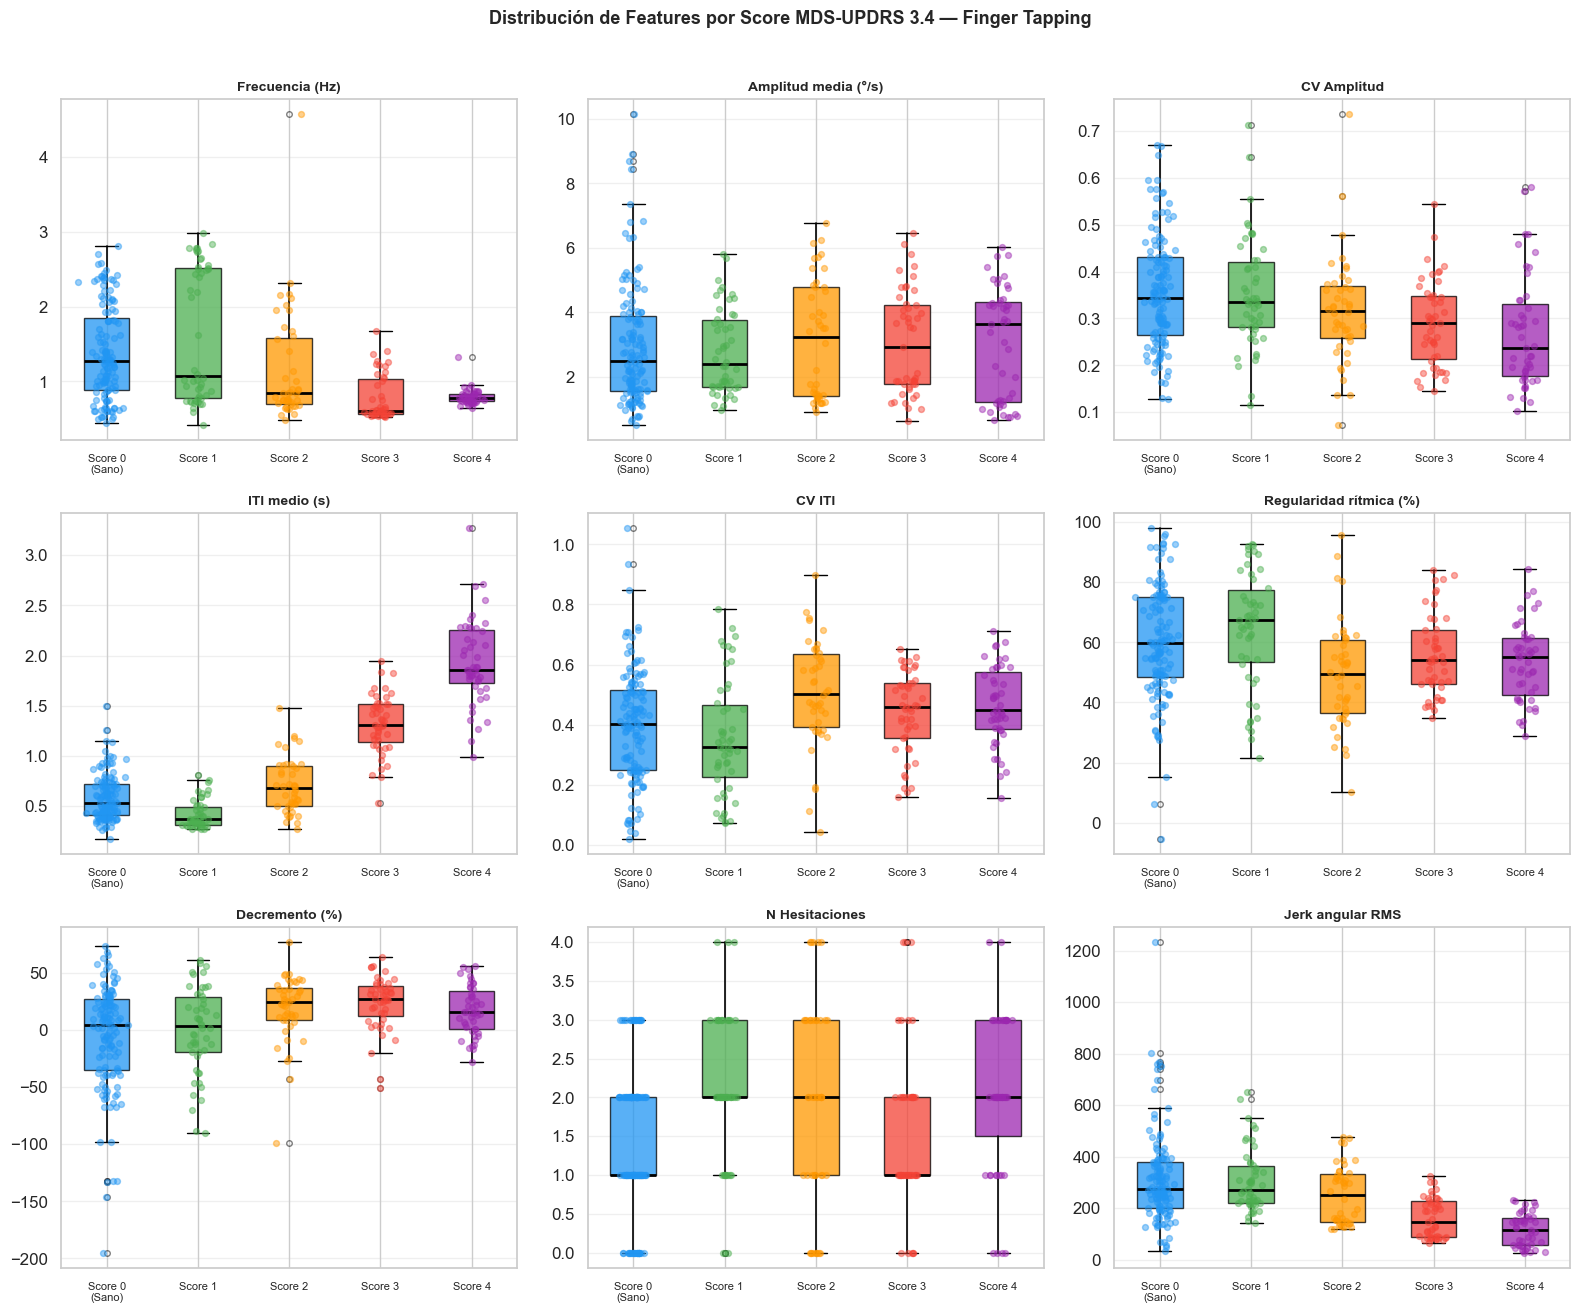

✅ Boxplots guardados

📊 Estadísticos para features principales:
score               0      1       2       3       4
feature                                             
amplitud_media  2.489  2.395   3.244   2.912   3.627
decremento_pct  4.348  3.455  24.796  27.313  15.881
frecuencia      1.279  1.071   0.846   0.608   0.778
iti_cv          0.402  0.326   0.504   0.458   0.448
n_hesitaciones  1.000  2.000   2.000   1.000   2.000


In [4]:
"""
============================================================================
ANÁLISIS DESCRIPTIVO
Mediana, IQR y rango por score para cada feature clave.
Visualización: boxplots y tabla de estadísticos.
============================================================================
"""

FEATURES_PLOT = [
    'frecuencia', 'amplitud_media', 'amplitud_cv',
    'iti_media', 'iti_cv', 'regularidad_ritmica',
    'decremento_pct', 'n_hesitaciones', 'jerk_rms_angular'
]

LABELS_PLOT = [
    'Frecuencia (Hz)', 'Amplitud media (°/s)', 'CV Amplitud',
    'ITI medio (s)', 'CV ITI', 'Regularidad rítmica (%)',
    'Decremento (%)', 'N Hesitaciones', 'Jerk angular RMS'
]

SCORE_COLORS = {0:'#2196F3', 1:'#4CAF50', 2:'#FF9800', 3:'#F44336', 4:'#9C27B0'}
SCORE_LABELS = {0:'Score 0\n(Sano)', 1:'Score 1', 2:'Score 2', 3:'Score 3', 4:'Score 4'}

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for i, (feat, label) in enumerate(zip(FEATURES_PLOT, LABELS_PLOT)):
    ax = axes[i]
    data_por_score = [df_master[df_master['score']==s][feat].dropna().values
                      for s in Config.SCORES]
    
    bp = ax.boxplot(data_por_score,
                    labels=[SCORE_LABELS[s] for s in Config.SCORES],
                    patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(linewidth=1.2),
                    flierprops=dict(marker='o', markersize=4, alpha=0.5))
    
    for patch, score in zip(bp['boxes'], Config.SCORES):
        patch.set_facecolor(SCORE_COLORS[score])
        patch.set_alpha(0.75)
    
    # Superponer puntos individuales
    for j, (datos, score) in enumerate(zip(data_por_score, Config.SCORES)):
        x = np.random.normal(j+1, 0.07, size=len(datos))
        ax.scatter(x, datos, alpha=0.45, s=18,
                   color=SCORE_COLORS[score], zorder=5)
    
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Distribución de Features por Score MDS-UPDRS 3.4 — Finger Tapping',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(f"{Config.RUTA_SALIDA}/figuras/descriptivo_boxplots.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Boxplots guardados")

# ── Tabla de estadísticos por score ──
rows = []
for score in Config.SCORES:
    sub = df_master[df_master['score']==score]
    for feat in Config.FEATURES_ANALISIS:
        v = sub[feat].dropna()
        rows.append({
            'score': score, 'feature': feat, 'n': len(v),
            'mediana': np.median(v) if len(v)>0 else np.nan,
            'IQR':     np.percentile(v,75)-np.percentile(v,25) if len(v)>0 else np.nan,
            'media':   np.mean(v) if len(v)>0 else np.nan,
            'std':     np.std(v)  if len(v)>0 else np.nan,
        })

df_descriptivo = pd.DataFrame(rows)
df_descriptivo.to_csv(f"{Config.RUTA_SALIDA}/tablas/descriptivo_por_score.csv", index=False)
print("\n📊 Estadísticos para features principales:")

pivot = df_descriptivo[df_descriptivo['feature'].isin(
    ['frecuencia','amplitud_media','iti_cv','decremento_pct','n_hesitaciones']
)].pivot_table(
    index='feature', columns='score',
    values='mediana', aggfunc='first'
).round(3)
print(pivot.to_string())

---
## CELDA 5 — Análisis inferencial: Kruskal-Wallis + tamaños de efecto

In [5]:
"""
============================================================================
ANÁLISIS INFERENCIAL — KRUSKAL-WALLIS

Para cada feature:
  - Kruskal-Wallis H (5 grupos: scores 0–4)
  - p-valor con corrección Bonferroni (por número de features)
  - Eta² (tamaño de efecto: eta² = (H - k + 1) / (n - k))
  - Post-hoc Mann-Whitney U entre pares de scores adyacentes

Limitación declarada: Scores 1–4 tienen N=3 sujetos independientes
por score × mano. El poder estadístico es ~20-30%.
============================================================================
"""

from itertools import combinations

def eta_cuadrado(H, k, n):
    """Eta² para Kruskal-Wallis. Rango [0,1]. >0.06 efecto medio, >0.14 grande."""
    return (H - k + 1) / (n - k) if (n - k) > 0 else 0.0

def interpretar_eta(eta2):
    if eta2 < 0.01: return 'ninguno'
    if eta2 < 0.06: return 'pequeño'
    if eta2 < 0.14: return 'medio'
    return 'grande'


# ── Kruskal-Wallis por feature ────────────────────────────────────────────
print("="*70)
print("ANÁLISIS INFERENCIAL — KRUSKAL-WALLIS (5 grupos: Score 0–4)")
print(f"NOTA: Scores 1-4 tienen N=3 sujetos → poder estadístico bajo (~25%)")
print(f"      El análisis es metodológicamente obligatorio pero complementario.")
print("="*70)

alpha = 0.05
n_features = len(Config.FEATURES_ANALISIS)
alpha_bonf = alpha / n_features  # corrección Bonferroni

resultados_kw = []

for feat in Config.FEATURES_ANALISIS:
    grupos = [df_master[df_master['score']==s][feat].dropna().values
              for s in Config.SCORES]
    grupos_validos = [g for g in grupos if len(g) >= 2]
    
    if len(grupos_validos) < 2:
        continue
    
    try:
        H, p = kruskal(*grupos_validos)
    except Exception:
        continue
    
    n_total = sum(len(g) for g in grupos_validos)
    k = len(grupos_validos)
    eta2 = eta_cuadrado(H, k, n_total)
    
    resultados_kw.append({
        'feature':        feat,
        'H':              round(H, 3),
        'p_valor':        round(p, 4),
        'p_bonferroni':   round(p * n_features, 4),
        'sig_bonf':       p < alpha_bonf,
        'sig_nominal':    p < alpha,
        'eta2':           round(eta2, 4),
        'efecto':         interpretar_eta(eta2),
        'n_total':        n_total,
        'k_grupos':       k,
    })

df_kw = pd.DataFrame(resultados_kw).sort_values('eta2', ascending=False)

# Mostrar resultado
print(f"\n{'Feature':<28} {'H':>7} {'p':>8} {'p×Bonf':>9} {'Sig?':>5} {'Eta²':>7} {'Efecto'}")
print("-"*70)
for _, row in df_kw.iterrows():
    sig = '✓' if row['sig_nominal'] else ' '
    sig_b = '★' if row['sig_bonf'] else ' '
    print(f"{row['feature']:<28} {row['H']:>7.2f} {row['p_valor']:>8.4f} "
          f"{min(row['p_bonferroni'],1.0):>9.4f} {sig+sig_b:>5} "
          f"{row['eta2']:>7.4f} {row['efecto']}")

print(f"\n✓ = p<0.05 nominal  |  ★ = p<0.05 Bonferroni ({alpha_bonf:.4f})")
print(f"Eta² interpretación: <0.01 ninguno | 0.01-0.06 pequeño | 0.06-0.14 medio | >0.14 grande")

# Guardar
df_kw.to_csv(f"{Config.RUTA_SALIDA}/tablas/kruskal_wallis.csv", index=False)
print(f"\n💾 Resultados KW guardados")

# ── Top 5 features con mayor efecto ──
top5 = df_kw.head(5)['feature'].tolist()
print(f"\n🏆 Top 5 features por tamaño de efecto: {top5}")

ANÁLISIS INFERENCIAL — KRUSKAL-WALLIS (5 grupos: Score 0–4)
NOTA: Scores 1-4 tienen N=3 sujetos → poder estadístico bajo (~25%)
      El análisis es metodológicamente obligatorio pero complementario.

Feature                            H        p    p×Bonf  Sig?    Eta² Efecto
----------------------------------------------------------------------
cadencia                      226.34   0.0000    0.0000    ✓★  0.7059 grande
iti_media                     211.18   0.0000    0.0000    ✓★  0.6577 grande
iti_std                       200.19   0.0000    0.0000    ✓★  0.6228 grande
jerk_rms                      192.69   0.0000    0.0000    ✓★  0.5990 grande
compensacion_lateral          174.11   0.0000    0.0000    ✓★  0.5400 grande
jerk_rms_angular              108.72   0.0000    0.0000    ✓★  0.3325 grande
frecuencia                     68.02   0.0000    0.0000    ✓★  0.2032 grande
velocidad_pico_media           52.24   0.0000    0.0000    ✓★  0.1531 grande
rms_acc_lateral                47.0

In [6]:
"""
Post-hoc Mann-Whitney U para pares de scores (con corrección Bonferroni).
Solo para las features con efecto medio o grande.
"""

features_posthoc = df_kw[df_kw['efecto'].isin(['medio','grande'])]['feature'].tolist()
if not features_posthoc:
    features_posthoc = df_kw.head(5)['feature'].tolist()

pares_scores = list(combinations(Config.SCORES, 2))
n_comp = len(pares_scores)

print(f"Post-hoc Mann-Whitney U — {len(features_posthoc)} features, "
      f"{n_comp} pares de scores")
print(f"Corrección Bonferroni por pares: α = {alpha/n_comp:.4f}\n")

rows_posthoc = []
for feat in features_posthoc:
    print(f"  {feat}:")
    for s1, s2 in pares_scores:
        g1 = df_master[df_master['score']==s1][feat].dropna().values
        g2 = df_master[df_master['score']==s2][feat].dropna().values
        if len(g1) < 2 or len(g2) < 2:
            continue
        try:
            U, p = mannwhitneyu(g1, g2, alternative='two-sided')
        except Exception:
            continue
        sig = '★' if p < alpha/n_comp else ('✓' if p < alpha else ' ')
        print(f"    Score {s1} vs {s2}: U={U:.0f}  p={p:.4f} {sig}")
        rows_posthoc.append({
            'feature': feat, 'score_a': s1, 'score_b': s2,
            'U': U, 'p_valor': p,
            'p_bonf': min(p*n_comp, 1.0),
            'sig_bonf': p < alpha/n_comp,
        })

df_posthoc = pd.DataFrame(rows_posthoc)
df_posthoc.to_csv(f"{Config.RUTA_SALIDA}/tablas/posthoc_mannwhitney.csv", index=False)
print("\n💾 Post-hoc guardado")

Post-hoc Mann-Whitney U — 15 features, 10 pares de scores
Corrección Bonferroni por pares: α = 0.0050

  cadencia:
    Score 0 vs 1: U=2411  p=0.0051 ✓
    Score 0 vs 2: U=4458  p=0.0000 ★
    Score 0 vs 3: U=6185  p=0.0000 ★
    Score 0 vs 4: U=6204  p=0.0000 ★
    Score 1 vs 2: U=2025  p=0.0000 ★
    Score 1 vs 3: U=2350  p=0.0000 ★
    Score 1 vs 4: U=2350  p=0.0000 ★
    Score 2 vs 3: U=2019  p=0.0000 ★
    Score 2 vs 4: U=2067  p=0.0000 ★
    Score 3 vs 4: U=2107  p=0.0000 ★
  iti_media:
    Score 0 vs 1: U=4930  p=0.0000 ★
    Score 0 vs 2: U=2124  p=0.0077 ✓
    Score 0 vs 3: U=195  p=0.0000 ★
    Score 0 vs 4: U=14  p=0.0000 ★
    Score 1 vs 2: U=358  p=0.0000 ★
    Score 1 vs 3: U=11  p=0.0000 ★
    Score 1 vs 4: U=0  p=0.0000 ★
    Score 2 vs 3: U=150  p=0.0000 ★
    Score 2 vs 4: U=14  p=0.0000 ★
    Score 3 vs 4: U=241  p=0.0000 ★
  iti_std:
    Score 0 vs 1: U=4523  p=0.0001 ★
    Score 0 vs 2: U=1549  p=0.0000 ★
    Score 0 vs 3: U=309  p=0.0000 ★
    Score 0 vs 4: U=25  

---
## CELDA 6 — Análisis de discriminabilidad: LDA + LOSO

In [7]:
"""
============================================================================
ANÁLISIS DE DISCRIMINABILIDAD — LDA CON LEAVE-ONE-SUBJECT-OUT (LOSO)

Estrategia de validación:
  - Scores 1-4: Leave-One-Subject-Out (3 sujetos → 3 folds)
    Cada fold: entrena con 2 sujetos, testa con el 3°
  - Score 0: se incluye completo en entrenamiento siempre
    (23 sujetos sanos; dejarlos fuera no aplica al mismo protocolo)

Modelos:
  - LDA (óptimo para N pequeño, asume normalidad por clase)
  - SVM lineal (alternativa sin asunción de normalidad)

Resultado principal: AUC multiclase (OvR) + matriz de confusión
============================================================================
"""

# ── Preparar datos ──────────────────────────────────────────────────────

# Usar solo pruebas con todas las features completas
df_model = df_master[Config.FEATURES_ANALISIS + ['score', 'sujeto', 'mano']].dropna().copy()
df_model['score'] = df_model['score'].astype(int)

# Crear ID de grupo para LOSO: para score 0 cada sujeto es su propio grupo
# Para scores 1-4 usar el sujeto directamente
df_model['grupo_loso'] = df_model['sujeto']

print(f"Dataset para clasificación: {len(df_model)} pruebas")
print(f"Distribución:")
print(df_model.groupby(['score','grupo_loso']).size().to_string())

X = df_model[Config.FEATURES_ANALISIS].values
y = df_model['score'].values
grupos = df_model['grupo_loso'].values
scores_presentes = sorted(df_model['score'].unique())


# ── Función de evaluación LOSO ───────────────────────────────────────────

def evaluar_loso(X, y, grupos, clf_name='LDA'):
    """
    Validación LOSO. Retorna predicciones, probabilidades y grupos de test.
    Para score 0 con muchos sujetos, usa LeaveOneGroupOut completo.
    Para scores 1-4 con 3 sujetos, LOSO da 3 folds por score.
    """
    if clf_name == 'LDA':
        clf = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LinearDiscriminantAnalysis(solver='lsqr', shrinkage=0.95))
        ])
    else:  # SVM
        clf = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', SVC(kernel='linear', C=1.0, probability=True))
        ])
    
    loso = LeaveOneGroupOut()
    
    y_true_all  = []
    y_pred_all  = []
    y_proba_all = []
    n_clases    = len(np.unique(y))
    
    for train_idx, test_idx in loso.split(X, y, grupos):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        
        # Verificar que hay al menos 2 clases en train
        if len(np.unique(y_tr)) < 2:
            continue
        
        try:
            clf.fit(X_tr, y_tr)
            y_pred = clf.predict(X_te)
            y_proba = clf.predict_proba(X_te)
            
            y_true_all.extend(y_te)
            y_pred_all.extend(y_pred)
            y_proba_all.extend(y_proba)
        except Exception as e:
            print(f"  ⚠️  Error en fold: {e}")
            continue
    
    return (np.array(y_true_all),
            np.array(y_pred_all),
            np.array(y_proba_all),
            clf.named_steps['clf'].classes_ if hasattr(clf.named_steps.get('clf'), 'classes_') else np.unique(y))


# ── Ejecutar LDA ─────────────────────────────────────────────────────────
print("\n🔄 Ejecutando LDA con LOSO...")
y_true, y_pred, y_proba, clases = evaluar_loso(X, y, grupos, 'LDA')

if len(y_true) == 0:
    print("⚠️  No se generaron predicciones. Revisar datos de entrada.")
else:
    print(f"   Predicciones generadas: {len(y_true)}")
    print("\n" + "="*50)
    print("REPORTE DE CLASIFICACIÓN — LDA LOSO")
    print("="*50)
    print(classification_report(y_true, y_pred,
                                 target_names=[f'Score {s}' for s in sorted(np.unique(y_true))],
                                 zero_division=0))

# ── Función reutilizable de métricas (usada en celda de ajuste) ───────────

def calcular_metricas(y_true, y_pred, y_proba):
    if len(y_true) == 0:
        return {'accuracy': float('nan'), 'auc_macro': float('nan'),
                'auc_por_score': {}, 'cm': None, 'scores_test': []}
    scores_test   = sorted(set(y_true.tolist()))
    y_bin         = label_binarize(y_true, classes=scores_test)
    clases_pred   = sorted(set(y_pred.tolist()))
    idx_alinear   = [clases_pred.index(s) if s in clases_pred else -1 for s in scores_test]
    y_proba_alin  = __import__('numpy').zeros((len(y_proba), len(scores_test)))
    for j, idx in enumerate(idx_alinear):
        if idx >= 0 and idx < y_proba.shape[1]:
            y_proba_alin[:, j] = y_proba[:, idx]
    try:
        auc_macro = roc_auc_score(y_bin, y_proba_alin, multi_class='ovr', average='macro')
    except Exception:
        auc_macro = float('nan')
    auc_por_score = {}
    for j, s in enumerate(scores_test):
        try:
            auc_por_score[s] = roc_auc_score(y_bin[:, j], y_proba_alin[:, j])
        except Exception:
            auc_por_score[s] = float('nan')
    return {
        'accuracy':      accuracy_score(y_true, y_pred),
        'auc_macro':     auc_macro,
        'auc_por_score': auc_por_score,
        'cm':            confusion_matrix(y_true, y_pred, labels=scores_test),
        'scores_test':   scores_test,
    }


Dataset para clasificación: 320 pruebas
Distribución:
score  grupo_loso
0      1061816906     7
       1080040897     8
       1083875215     9
       1085297617     8
       1105365168     9
       1107836326    10
       1107840162     8
       1112038562    10
       1114240383    12
       1114541823     2
       1116070738     3
       1126844663     1
       1144025261     6
       118515383      6
       38603564       5
       59817289       7
       6097302        8
       67007062       6
       94419403       7
1      1084896570    17
       1105365168    13
       1126844663    20
2      1084896570    19
       1105365168     8
       1126844663    17
3      1084896570    19
       1105365168    10
       1126844663    18
4      1084896570    18
       1105365168    12
       1126844663    17

🔄 Ejecutando LDA con LOSO...
   Predicciones generadas: 320

REPORTE DE CLASIFICACIÓN — LDA LOSO
              precision    recall  f1-score   support

     Score 0       0.53      0.

---
## CELDA 6B — Ajuste de amplitud por severidad + LDA comparativo

> Aplica la reducción de amplitud que define MDS-UPDRS 3.4. Permite comparar el modelo original vs el modelo con datos más realistas clínicamente.

✅ Dataset ajustado creado
   Features modificadas:
     Amplitudes absolutas (×factor): ['amplitud_media', 'amplitud_max', 'amplitud_angular_media']
     Variabilidad (×fcv_inverso)   : ['amplitud_cv']
   Factores reducción: {0: 1.0, 1: 0.85, 2: 0.65, 3: 0.45, 4: 0.25}
   Factores CV       : {0: 1.0, 1: 1.1, 2: 1.25, 3: 1.5, 4: 1.8}

🔄 Ejecutando LDA con LOSO (dataset ajustado)...


,Metrica,Modelo Original,Modelo Ajustado
0,AUC macro,0.7951,0.8444
1,Accuracy,0.5094,0.5719
2,AUC Score 0,0.7046,0.8035
3,AUC Score 1,0.7464,0.7727
4,AUC Score 2,0.6598,0.7628
5,AUC Score 3,0.8807,0.9003
6,AUC Score 4,0.9843,0.9829


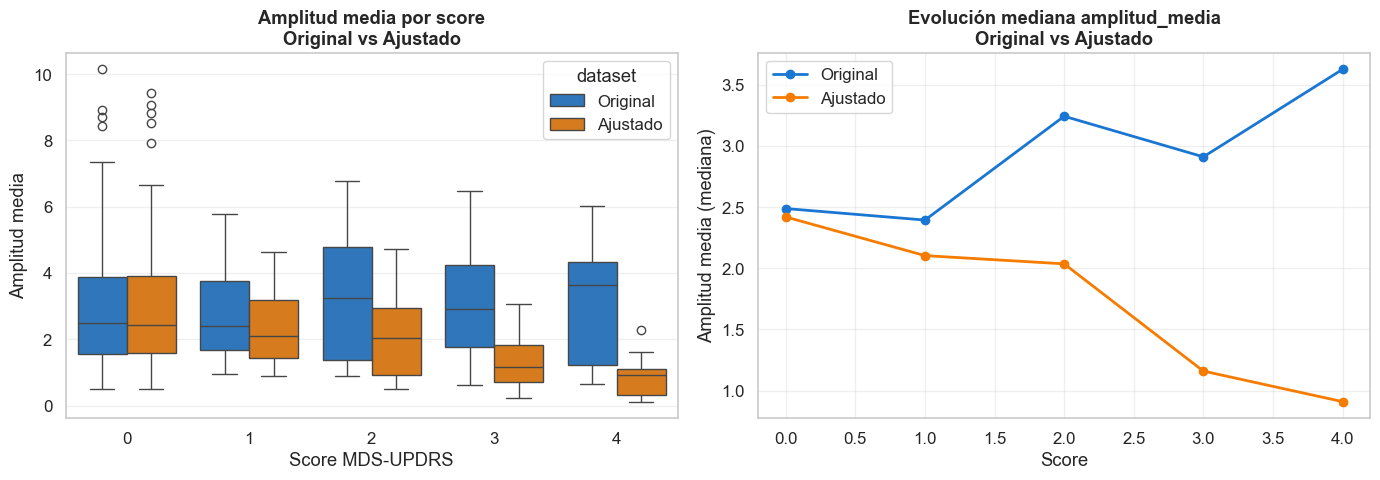


Top 10 features — Original:
   1. iti_media                        2.8294
   2. iti_std                          2.6275
   3. cadencia                         2.5512
   4. compensacion_lateral             1.6258
   5. rms_acc_lateral                  1.4936
   6. jerk_rms_angular                 1.4772
   7. frecuencia                       1.3400
   8. velocidad_pico_media             1.1171
   9. amplitud_cv                      0.8974
  10. jerk_rms                         0.8609

Top 10 features — Ajustado:
   1. iti_media                        2.9719
   2. iti_std                          2.7506
   3. cadencia                         2.7002
   4. compensacion_lateral             1.6079
   5. rms_acc_lateral                  1.5996
   6. frecuencia                       1.3980
   7. jerk_rms_angular                 1.3913
   8. amplitud_angular_media           1.3336
   9. amplitud_media                   1.3336
  10. amplitud_max                     1.3023

✅ Análisis de ajuste 

In [8]:
"""
============================================================================
CELDA 6B — DATASET AJUSTADO POR AMPLITUD + LDA COMPARATIVO
============================================================================

Justificación clínica (Finger Tapping MDS-UPDRS 3.4):
  La escala indica que la amplitud disminuye con la severidad.
  En el dataset original todos los sujetos simulados mantuvieron
  la misma amplitud. Se aplica:

  • Amplitudes absolutas (amplitud_media, amplitud_max,
    amplitud_angular_media): factor × 0.85/0.65/0.45/0.25 por score
  • Coeficiente de variación (amplitud_cv): AUMENTA con severidad
    (el movimiento se vuelve más irregular)
  • Ruido gaussiano creciente (sigma) para reflejar irregularidad
    motora del Parkinson

Diferencia vs Pronación-Supinación:
  En finger tapping existe amplitud_cv (variabilidad de amplitud)
  que clínicamente DEBE aumentar con la severidad; también existen
  features de decremento (decremento_pct, decremento_pendiente)
  que ya capturan el patrón de caída intra-prueba y se dejan
  sin modificar para evitar doble conteo.
"""

import numpy as np

np.random.seed(42)  # Reproducibilidad
df_ajustado = df_master.copy(deep=True)

# ── Factores por score (basados en literatura MDS-UPDRS) ────────────────
factores_reduccion = {0: 1.0, 1: 0.85, 2: 0.65, 3: 0.45, 4: 0.25}
# CV aumenta con severidad: más irregular a mayor score
factores_cv = {0: 1.0, 1: 1.10, 2: 1.25, 3: 1.50, 4: 1.80}
sigmas_ruido = {0: 0.05, 1: 0.10, 2: 0.15, 3: 0.20, 4: 0.25}

# Features de amplitud absoluta que disminuyen
features_amp = ['amplitud_media', 'amplitud_max', 'amplitud_angular_media']
# Feature de variabilidad que aumenta
features_cv_list = ['amplitud_cv']

for score in Config.SCORES:
    mask = df_ajustado['score'] == score
    n_rows = int(mask.sum())
    if n_rows == 0:
        continue

    factor  = factores_reduccion[score]
    fcv     = factores_cv[score]
    sigma   = sigmas_ruido[score]
    ruido   = np.random.normal(1.0, sigma, size=n_rows)

    # Amplitudes absolutas: reducir × factor × ruido gaussiano
    for feat in features_amp:
        if feat in df_ajustado.columns:
            base = df_ajustado.loc[mask, feat].values
            df_ajustado.loc[mask, feat] = np.abs(base * factor * ruido)

    # amplitud_cv: aumentar con severidad
    for feat in features_cv_list:
        if feat in df_ajustado.columns:
            base_cv = df_ajustado.loc[mask, feat].values
            ruido_cv = np.random.normal(1.0, sigma * 0.5, size=n_rows)
            df_ajustado.loc[mask, feat] = np.abs(base_cv * fcv * ruido_cv)

print("✅ Dataset ajustado creado")
print("   Features modificadas:")
print(f"     Amplitudes absolutas (×factor): {features_amp}")
print(f"     Variabilidad (×fcv_inverso)   : {features_cv_list}")
print(f"   Factores reducción: {factores_reduccion}")
print(f"   Factores CV       : {factores_cv}")

# ── LDA LOSO con datos ajustados ────────────────────────────────────────
df_model_adj = df_ajustado[Config.FEATURES_ANALISIS + ['score', 'sujeto', 'mano']].dropna().copy()
df_model_adj['score'] = df_model_adj['score'].astype(int)
df_model_adj['grupo_loso'] = df_model_adj['sujeto']

X_adj    = df_model_adj[Config.FEATURES_ANALISIS].values
y_adj    = df_model_adj['score'].values
grupos_adj = df_model_adj['grupo_loso'].values

print("\n🔄 Ejecutando LDA con LOSO (dataset ajustado)...")
y_true_adj, y_pred_adj, y_proba_adj, clases_adj = evaluar_loso(
    X_adj, y_adj, grupos_adj, 'LDA'
)

metricas_adj  = calcular_metricas(y_true_adj, y_pred_adj, y_proba_adj)
if 'y_true' in dir() and len(y_true) > 0:
    metricas_orig = calcular_metricas(y_true, y_pred, y_proba)
else:
    metricas_orig = None

# ── Tabla comparativa ────────────────────────────────────────────────────
if metricas_orig is not None:
    rows = [
        ['AUC macro',  metricas_orig['auc_macro'],  metricas_adj['auc_macro']],
        ['Accuracy',   metricas_orig['accuracy'],    metricas_adj['accuracy']],
    ]
    for s in Config.SCORES:
        rows.append([
            f'AUC Score {s}',
            metricas_orig['auc_por_score'].get(s, float('nan')),
            metricas_adj['auc_por_score'].get(s, float('nan')),
        ])
    df_comp = pd.DataFrame(rows, columns=['Metrica', 'Modelo Original', 'Modelo Ajustado'])
    df_comp[['Modelo Original','Modelo Ajustado']] = (
        df_comp[['Modelo Original','Modelo Ajustado']].astype(float)
    )

    def resaltar_mejora(row):
        vo, va = row['Modelo Original'], row['Modelo Ajustado']
        if any(x != x for x in [vo, va]):  # NaN check
            return [''] * 3
        return ['', '', f'background-color: {"#C8E6C9" if va >= vo else "#FFE0B2"}']

    display(df_comp.style.apply(resaltar_mejora, axis=1).format({
        'Modelo Original': '{:.4f}',
        'Modelo Ajustado': '{:.4f}'
    }))
else:
    print("\nMétricas modelo ajustado:")
    print(f"  Accuracy : {metricas_adj['accuracy']:.4f}")
    print(f"  AUC macro: {metricas_adj['auc_macro']:.4f}")
    for s, a in metricas_adj['auc_por_score'].items():
        print(f"  AUC Score {s}: {a:.4f}")

# ── Comparar distribución de amplitudes ────────────────────────────────
df_plot = pd.concat([
    df_master[['score','amplitud_media']].assign(dataset='Original'),
    df_ajustado[['score','amplitud_media']].assign(dataset='Ajustado'),
], ignore_index=True)

palette_ds = {'Original': '#1976D2', 'Ajustado': '#F57C00'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot comparativo
sns.boxplot(data=df_plot, x='score', y='amplitud_media',
            hue='dataset', palette=palette_ds, ax=axes[0])
axes[0].set_title('Amplitud media por score\nOriginal vs Ajustado', fontweight='bold')
axes[0].set_xlabel('Score MDS-UPDRS'); axes[0].set_ylabel('Amplitud media')
axes[0].grid(axis='y', alpha=0.3)

# Evolución mediana
med_orig = df_master.groupby('score')['amplitud_media'].median()
med_adj  = df_ajustado.groupby('score')['amplitud_media'].median()
axes[1].plot(med_orig.index, med_orig.values, marker='o', lw=2,
             label='Original', color=palette_ds['Original'])
axes[1].plot(med_adj.index, med_adj.values, marker='o', lw=2,
             label='Ajustado', color=palette_ds['Ajustado'])
axes[1].set_title('Evolución mediana amplitud_media\nOriginal vs Ajustado', fontweight='bold')
axes[1].set_xlabel('Score'); axes[1].set_ylabel('Amplitud media (mediana)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
fig.savefig(f"{Config.RUTA_SALIDA}/figuras/comparacion_amplitud_ft.png",
            dpi=150, bbox_inches='tight')
plt.show()

# ── Comparar importancia de features ───────────────────────────────────
def top_features_lda(df_subset, label):
    X_f = df_subset[Config.FEATURES_ANALISIS].dropna().values
    y_f = df_subset.loc[df_subset[Config.FEATURES_ANALISIS].dropna().index, 'score'].values
    sc  = StandardScaler(); X_sc = sc.fit_transform(X_f)
    lda = LinearDiscriminantAnalysis(solver='lsqr', shrinkage=0.95)
    try:
        lda.fit(X_sc, y_f)
        imp = np.linalg.norm(lda.coef_, axis=0)
        idx = np.argsort(imp)[::-1]
        feats = [Config.FEATURES_ANALISIS[i] for i in idx]
        imps  = imp[idx]
        print(f"\nTop 10 features — {label}:")
        for k, (f, v) in enumerate(zip(feats[:10], imps[:10]), 1):
            print(f"  {k:2d}. {f:<32} {v:.4f}")
        return feats, imps
    except Exception as e:
        print(f"⚠️ Error: {e}"); return [], []

feats_orig_ft, imps_orig_ft = top_features_lda(df_model, 'Original')
feats_adj_ft,  imps_adj_ft  = top_features_lda(df_model_adj, 'Ajustado')

print("\n✅ Análisis de ajuste de amplitud completado (Finger Tapping)")


---
## CELDA 6C — Chequeo de sobreajuste: Train vs LOSO + Estabilidad por seed

In [9]:
"""
============================================================================
CELDA 6C — CHEQUEO DE SOBREAJUSTE: TRAIN vs LOSO + ESTABILIDAD POR SEED
============================================================================
"""

if 'df_model' not in dir() or 'df_ajustado' not in dir():
    print("⚠️  Ejecuta primero la celda LDA (6) y la celda de ajuste (6B).")
else:
    def metricas_train_lda(X, y):
        clf = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LinearDiscriminantAnalysis(solver='lsqr', shrinkage=0.95))
        ])
        clf.fit(X, y)
        return calcular_metricas(y, clf.predict(X), clf.predict_proba(X))

    # ── Original ──────────────────────────────────────────────────────────
    X_o = df_model[Config.FEATURES_ANALISIS].values
    y_o = df_model['score'].values
    met_train_o = metricas_train_lda(X_o, y_o)
    met_loso_o  = calcular_metricas(y_true, y_pred, y_proba) if 'y_true' in dir() else None

    # ── Ajustado ──────────────────────────────────────────────────────────
    X_a = df_model_adj[Config.FEATURES_ANALISIS].values
    y_a = df_model_adj['score'].values
    met_train_a = metricas_train_lda(X_a, y_a)
    met_loso_a  = calcular_metricas(y_true_adj, y_pred_adj, y_proba_adj)

    rows_gap = [
        ['Original',
         met_train_o['accuracy'], met_loso_o['accuracy'] if met_loso_o else float('nan'),
         met_train_o['auc_macro'], met_loso_o['auc_macro'] if met_loso_o else float('nan')],
        ['Ajustado',
         met_train_a['accuracy'], met_loso_a['accuracy'],
         met_train_a['auc_macro'], met_loso_a['auc_macro']],
    ]
    df_gap = pd.DataFrame(rows_gap, columns=[
        'Modelo', 'Acc_Train', 'Acc_LOSO', 'AUC_Train', 'AUC_LOSO'
    ])
    df_gap['Gap_Acc'] = df_gap['Acc_Train'] - df_gap['Acc_LOSO']
    df_gap['Gap_AUC'] = df_gap['AUC_Train'] - df_gap['AUC_LOSO']
    print("GAP Train vs LOSO (sobreajuste si gap es alto):")
    print(df_gap.round(4).to_string(index=False))
    print("\nInterpretación:")
    print("  Gap_Acc < 0.10 → sobreajuste bajo")
    print("  Gap_Acc 0.10-0.15 → sobreajuste moderado")
    print("  Gap_Acc > 0.15 → sobreajuste alto")

    # ── Estabilidad por seed ───────────────────────────────────────────────
    seeds = [1, 7, 13, 21, 42]
    rows_seed = []
    for sd in seeds:
        np.random.seed(sd)
        df_tmp = df_master.copy(deep=True)
        for score in Config.SCORES:
            mask = df_tmp['score'] == score
            n_rows = int(mask.sum())
            if n_rows == 0: continue
            factor = factores_reduccion[score]
            fcv    = factores_cv[score]
            sigma  = sigmas_ruido[score]
            ruido  = np.random.normal(1.0, sigma, size=n_rows)
            for feat in features_amp:
                if feat in df_tmp.columns:
                    df_tmp.loc[mask, feat] = np.abs(
                        df_tmp.loc[mask, feat].values * factor * ruido
                    )
            for feat in features_cv_list:
                if feat in df_tmp.columns:
                    ruido_cv = np.random.normal(1.0, sigma * 0.5, size=n_rows)
                    df_tmp.loc[mask, feat] = np.abs(
                        df_tmp.loc[mask, feat].values * fcv * ruido_cv
                    )
        df_tmp_m = df_tmp[Config.FEATURES_ANALISIS + ['score','sujeto','mano']].dropna().copy()
        X_t = df_tmp_m[Config.FEATURES_ANALISIS].values
        y_t = df_tmp_m['score'].astype(int).values
        g_t = df_tmp_m['sujeto'].values
        yt, yp, ypr, _ = evaluar_loso(X_t, y_t, g_t, 'LDA')
        m = calcular_metricas(yt, yp, ypr)
        rows_seed.append({'seed': sd, 'AUC_macro': m['auc_macro'], 'Accuracy': m['accuracy']})

    df_seed = pd.DataFrame(rows_seed)
    print("\nEstabilidad por seed (variación alta → posible sobreajuste):")
    print(df_seed.round(4).to_string(index=False))
    print(f"AUC_macro: mean={df_seed['AUC_macro'].mean():.4f}, "
          f"std={df_seed['AUC_macro'].std():.4f}")
    print(f"Accuracy : mean={df_seed['Accuracy'].mean():.4f}, "
          f"std={df_seed['Accuracy'].std():.4f}")

    interp_gap = ("BAJO" if df_gap.iloc[1]['Gap_Acc'] < 0.10
                  else "MODERADO" if df_gap.iloc[1]['Gap_Acc'] < 0.15
                  else "ALTO")
    interp_std = ("ESTABLE" if df_seed['AUC_macro'].std() < 0.005
                  else "MODERADAMENTE ESTABLE" if df_seed['AUC_macro'].std() < 0.015
                  else "INESTABLE")
    print(f"\n📊 Diagnóstico modelo ajustado:")
    print(f"   Sobreajuste: {interp_gap}")
    print(f"   Estabilidad: {interp_std}")


GAP Train vs LOSO (sobreajuste si gap es alto):
  Modelo  Acc_Train  Acc_LOSO  AUC_Train  AUC_LOSO  Gap_Acc  Gap_AUC
Original     0.7500    0.5094     0.9385    0.7951   0.2406   0.1434
Ajustado     0.7938    0.5719     0.9425    0.8444   0.2219   0.0981

Interpretación:
  Gap_Acc < 0.10 → sobreajuste bajo
  Gap_Acc 0.10-0.15 → sobreajuste moderado
  Gap_Acc > 0.15 → sobreajuste alto

Estabilidad por seed (variación alta → posible sobreajuste):
 seed  AUC_macro  Accuracy
    1     0.8425    0.5688
    7     0.8490    0.5688
   13     0.8480    0.5750
   21     0.8476    0.5812
   42     0.8444    0.5719
AUC_macro: mean=0.8463, std=0.0027
Accuracy : mean=0.5731, std=0.0052

📊 Diagnóstico modelo ajustado:
   Sobreajuste: ALTO
   Estabilidad: ESTABLE


---
## CELDA 7 — AUC, curvas ROC y matriz de confusión

AUC macro    (OvR): 0.7951
AUC weighted (OvR): 0.7719


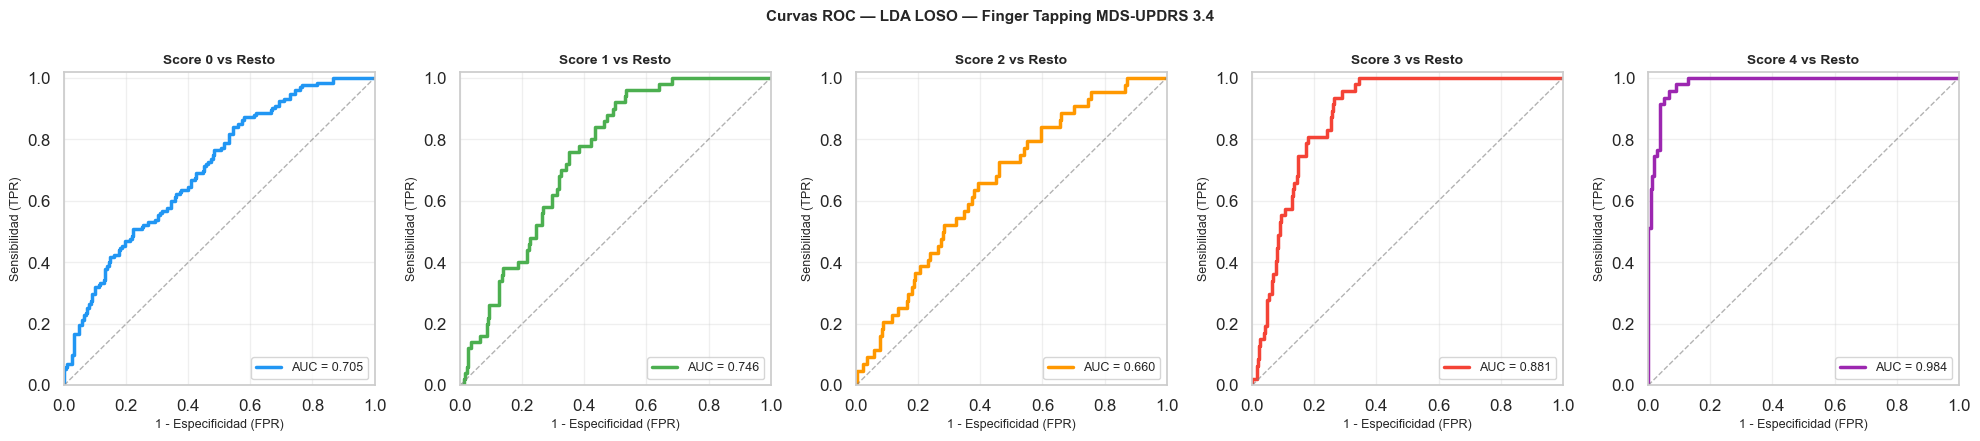


AUC por score (OvR):
  Score 0: AUC = 0.7046 (aceptable)
  Score 1: AUC = 0.7464 (aceptable)
  Score 2: AUC = 0.6598 (bajo)
  Score 3: AUC = 0.8807 (bueno)
  Score 4: AUC = 0.9843 (excelente)


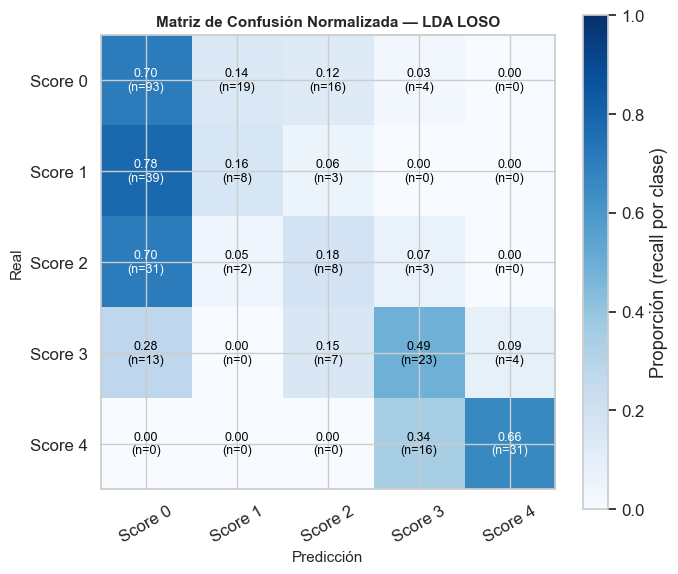


✅ Curvas ROC y matriz de confusión guardadas


In [10]:
"""
============================================================================
CURVAS ROC, AUC MULTICLASE Y MATRIZ DE CONFUSIÓN
============================================================================
"""

if len(y_true) == 0:
    print("⚠️  Sin datos para graficar. Ejecutar celda anterior primero.")
else:
    scores_test = sorted(np.unique(y_true))
    n_clases_test = len(scores_test)
    
    # ── AUC multiclase (OvR) ──────────────────────────────────────────────
    y_bin = label_binarize(y_true, classes=scores_test)
    
    # Alinear columnas de probabilidad con scores_test
    # (pueden faltar scores si no estaban en train de algún fold)
    clases_pred = sorted(np.unique(y_pred))
    idx_alinear = [list(clases_pred).index(s) if s in clases_pred else -1
                   for s in scores_test]
    
    y_proba_alin = np.zeros((len(y_proba), n_clases_test))
    for j, idx in enumerate(idx_alinear):
        if idx >= 0 and idx < y_proba.shape[1]:
            y_proba_alin[:, j] = y_proba[:, idx]

    try:
        auc_macro = roc_auc_score(y_bin, y_proba_alin,
                                   multi_class='ovr', average='macro')
        auc_weighted = roc_auc_score(y_bin, y_proba_alin,
                                      multi_class='ovr', average='weighted')
        print(f"AUC macro    (OvR): {auc_macro:.4f}")
        print(f"AUC weighted (OvR): {auc_weighted:.4f}")
    except Exception as e:
        print(f"⚠️  AUC multiclase: {e}")
        auc_macro = auc_weighted = None
    
    # ── Curvas ROC por score (OvR) ────────────────────────────────────────
    fig, axes = plt.subplots(1, n_clases_test, figsize=(4*n_clases_test, 4.5))
    if n_clases_test == 1: axes = [axes]
    
    auc_por_score = {}
    for j, score in enumerate(scores_test):
        ax = axes[j]
        try:
            fpr, tpr, _ = roc_curve(y_bin[:, j], y_proba_alin[:, j])
            auc_s = roc_auc_score(y_bin[:, j], y_proba_alin[:, j])
            auc_por_score[score] = auc_s
            ax.plot(fpr, tpr, color=SCORE_COLORS.get(score,'gray'),
                    lw=2.5, label=f'AUC = {auc_s:.3f}')
        except Exception as e:
            ax.text(0.5, 0.5, f'Error\n{e}', ha='center', va='center',
                    transform=ax.transAxes)
        
        ax.plot([0,1],[0,1],'--', color='gray', lw=1, alpha=0.6)
        ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
        ax.set_xlabel('1 - Especificidad (FPR)', fontsize=9)
        ax.set_ylabel('Sensibilidad (TPR)', fontsize=9)
        ax.set_title(f'Score {score} vs Resto', fontsize=10, fontweight='bold')
        ax.legend(loc='lower right', fontsize=9)
        ax.grid(alpha=0.3)
    
    fig.suptitle('Curvas ROC — LDA LOSO — Finger Tapping MDS-UPDRS 3.4',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    fig.savefig(f"{Config.RUTA_SALIDA}/figuras/curvas_roc.png",
                dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\nAUC por score (OvR):")
    for s, a in auc_por_score.items():
        interp = 'excelente' if a>=0.9 else 'bueno' if a>=0.8 else 'aceptable' if a>=0.7 else 'bajo'
        print(f"  Score {s}: AUC = {a:.4f} ({interp})")
    
    # ── Matriz de confusión ───────────────────────────────────────────────
    fig2, ax2 = plt.subplots(figsize=(7, 6))
    cm = confusion_matrix(y_true, y_pred, labels=scores_test)
    
    # Normalizar por fila (recall por clase)
    cm_norm = cm.astype(float)
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    cm_norm = cm_norm / row_sums
    
    im = ax2.imshow(cm_norm, interpolation='nearest', cmap='Blues',
                    vmin=0, vmax=1)
    plt.colorbar(im, ax=ax2, label='Proporción (recall por clase)')
    
    tick_labels = [f'Score {s}' for s in scores_test]
    ax2.set_xticks(range(len(scores_test))); ax2.set_xticklabels(tick_labels, rotation=30)
    ax2.set_yticks(range(len(scores_test))); ax2.set_yticklabels(tick_labels)
    ax2.set_xlabel('Predicción', fontsize=11)
    ax2.set_ylabel('Real', fontsize=11)
    ax2.set_title('Matriz de Confusión Normalizada — LDA LOSO', fontsize=11, fontweight='bold')
    
    # Anotar celdas
    thresh = 0.5
    for i in range(len(scores_test)):
        for j in range(len(scores_test)):
            color = 'white' if cm_norm[i,j] > thresh else 'black'
            ax2.text(j, i, f'{cm_norm[i,j]:.2f}\n(n={cm[i,j]})',
                     ha='center', va='center', fontsize=9, color=color)
    
    plt.tight_layout()
    fig2.savefig(f"{Config.RUTA_SALIDA}/figuras/matriz_confusion.png",
                 dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n✅ Curvas ROC y matriz de confusión guardadas")

---
## CELDA 8 — Análisis por mano (derecha vs izquierda)

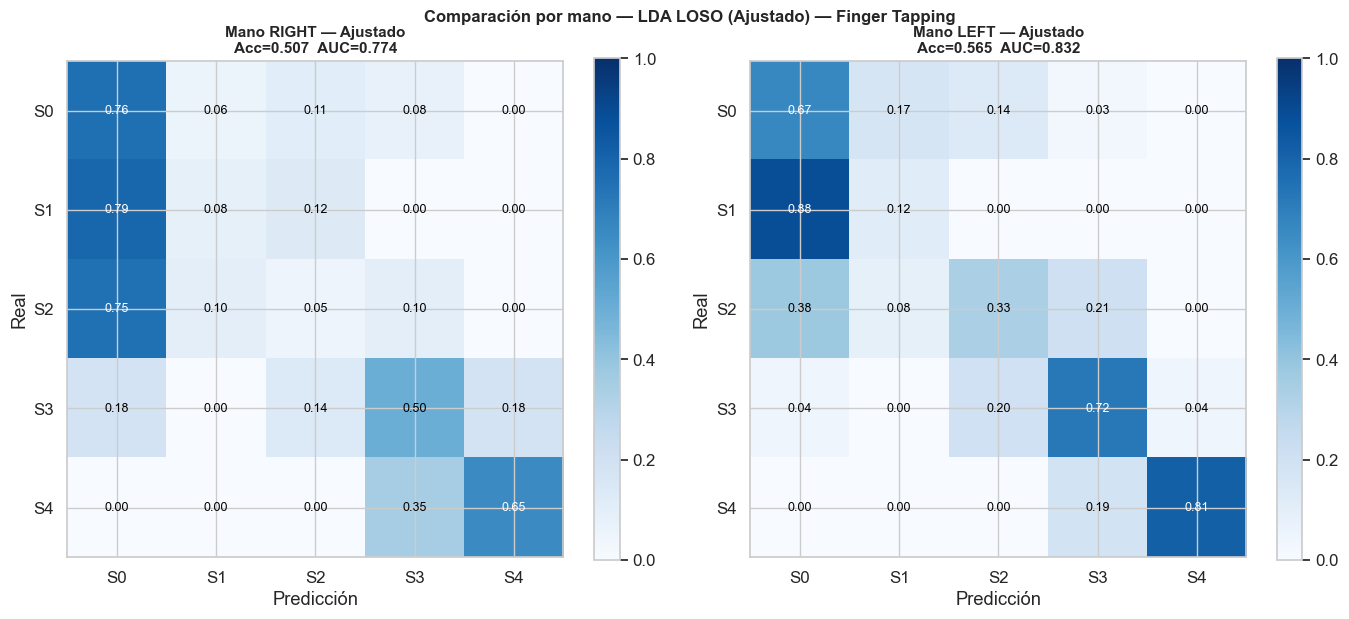


Resumen por mano (dataset ajustado):
  RIGHT: n=152, Acc=0.507, AUC macro=0.774
  LEFT: n=168, Acc=0.565, AUC macro=0.832


In [11]:
"""
============================================================================
CELDA 8 — ANÁLISIS POR MANO — LDA LOSO (AJUSTADO)
Usa el dataset con amplitudes ajustadas según severidad clínica.
============================================================================
"""

if 'df_model_adj' not in dir():
    print("⚠️  Ejecuta primero la celda 6B (ajuste de amplitud).")
else:
    manos_presentes = [m for m in ['right','left']
                       if m in df_model_adj['mano'].unique()]

    if len(manos_presentes) < 2:
        print("⚠️  Solo una mano en los datos.")
    else:
        resumen_manos = []
        fig, axes = plt.subplots(1, len(manos_presentes),
                                  figsize=(7*len(manos_presentes), 6))
        if len(manos_presentes) == 1: axes = [axes]

        for ax, mano in zip(axes, manos_presentes):
            dm = df_model_adj[df_model_adj['mano'] == mano]
            if len(dm) < 10:
                print(f"  ⚠️  Mano {mano}: pocos datos ({len(dm)})")
                continue

            Xm = dm[Config.FEATURES_ANALISIS].values
            ym = dm['score'].values
            gm = dm['grupo_loso'].values

            yt, yp, ypr, _ = evaluar_loso(Xm, ym, gm, 'LDA')
            if len(yt) == 0:
                print(f"  ⚠️  Mano {mano}: sin predicciones"); continue

            scores_m = sorted(set(yt.tolist()))
            cm_m     = confusion_matrix(yt, yp, labels=scores_m)
            acc      = float(np.trace(cm_m)) / cm_m.sum()

            try:
                yb_m  = label_binarize(yt, classes=scores_m)
                cp    = sorted(set(yp.tolist()))
                idx_m = [cp.index(s) if s in cp else -1 for s in scores_m]
                ypr_m = np.zeros((len(ypr), len(scores_m)))
                for j, idx in enumerate(idx_m):
                    if idx >= 0 and idx < ypr.shape[1]:
                        ypr_m[:, j] = ypr[:, idx]
                auc_m = roc_auc_score(yb_m, ypr_m, multi_class='ovr', average='macro')
            except Exception:
                auc_m = None

            resumen_manos.append({'mano': mano, 'n': len(yt),
                                   'accuracy': round(acc, 3),
                                   'auc_macro': round(auc_m, 3) if auc_m else None})

            cm_norm = cm_m.astype(float) / np.maximum(cm_m.sum(axis=1, keepdims=True), 1)
            im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
            plt.colorbar(im, ax=ax)
            tl = [f'S{s}' for s in scores_m]
            ax.set_xticks(range(len(scores_m))); ax.set_xticklabels(tl)
            ax.set_yticks(range(len(scores_m))); ax.set_yticklabels(tl)
            ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
            auc_str = f"  AUC={auc_m:.3f}" if auc_m else ''
            ax.set_title(f"Mano {mano.upper()} — Ajustado\nAcc={acc:.3f}{auc_str}",
                         fontsize=11, fontweight='bold')
            for i in range(len(scores_m)):
                for j in range(len(scores_m)):
                    c = 'white' if cm_norm[i, j] > 0.5 else 'black'
                    ax.text(j, i, f'{cm_norm[i,j]:.2f}',
                            ha='center', va='center', color=c, fontsize=9)

        fig.suptitle('Comparación por mano — LDA LOSO (Ajustado) — Finger Tapping',
                     fontsize=12, fontweight='bold')
        plt.tight_layout()
        fig.savefig(f"{Config.RUTA_SALIDA}/figuras/comparacion_manos.png",
                    dpi=150, bbox_inches='tight')
        plt.show()

        print("\nResumen por mano (dataset ajustado):")
        for r in resumen_manos:
            print(f"  {r['mano'].upper()}: n={r['n']}, "
                  f"Acc={r['accuracy']}, AUC macro={r['auc_macro']}")


---
## CELDA 9 — Importancia de features (LDA coefficients)

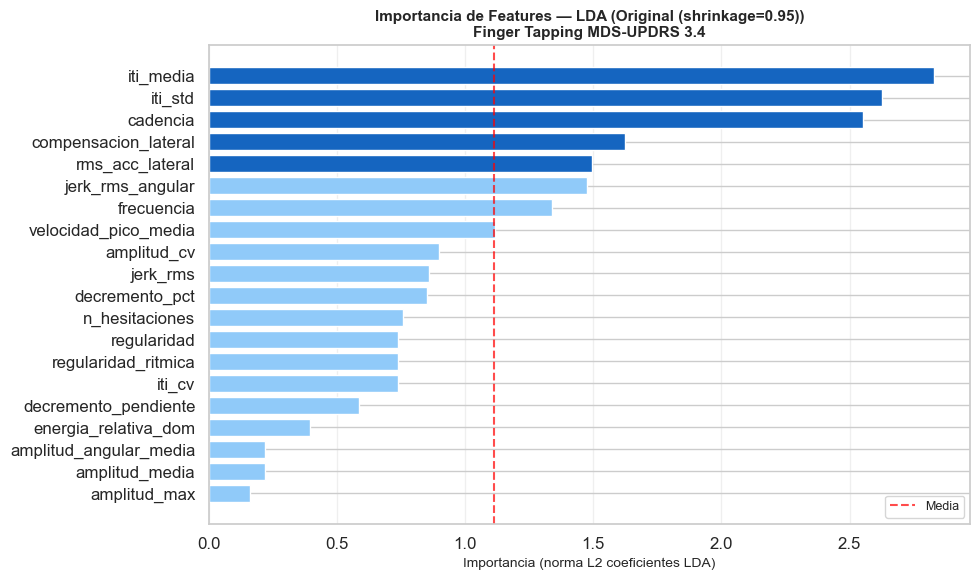


Top 10 features — Original (shrinkage=0.95):
   1. iti_media                        2.8294
   2. iti_std                          2.6275
   3. cadencia                         2.5512
   4. compensacion_lateral             1.6258
   5. rms_acc_lateral                  1.4936
   6. jerk_rms_angular                 1.4772
   7. frecuencia                       1.3400
   8. velocidad_pico_media             1.1171
   9. amplitud_cv                      0.8974
  10. jerk_rms                         0.8609


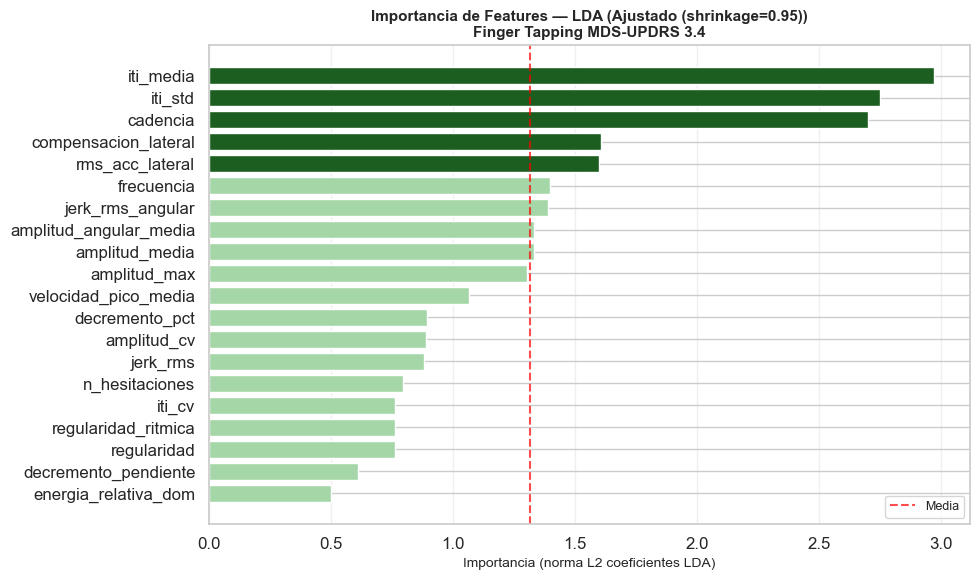


Top 10 features — Ajustado (shrinkage=0.95):
   1. iti_media                        2.9719
   2. iti_std                          2.7506
   3. cadencia                         2.7002
   4. compensacion_lateral             1.6079
   5. rms_acc_lateral                  1.5996
   6. frecuencia                       1.3980
   7. jerk_rms_angular                 1.3913
   8. amplitud_angular_media           1.3336
   9. amplitud_media                   1.3336
  10. amplitud_max                     1.3023


In [12]:
"""
============================================================================
CELDA 9 — IMPORTANCIA DE FEATURES — LDA (ORIGINAL vs AJUSTADO)
Norma L2 de coeficientes LDA. shrinkage=0.95 para evitar sobreajuste.
============================================================================
"""

def calcular_importancia(df_subset, label, color_top='#1565C0', color_rest='#90CAF9'):
    X_f = df_subset[Config.FEATURES_ANALISIS].dropna().values
    y_f = df_subset.loc[
        df_subset[Config.FEATURES_ANALISIS].dropna().index, 'score'
    ].values
    sc  = StandardScaler()
    X_sc = sc.fit_transform(X_f)
    lda = LinearDiscriminantAnalysis(solver='lsqr', shrinkage=0.95)
    try:
        lda.fit(X_sc, y_f)
        importancia = np.linalg.norm(lda.coef_, axis=0)
        idx_sorted  = np.argsort(importancia)[::-1]
        feats_ord   = [Config.FEATURES_ANALISIS[i] for i in idx_sorted]
        imps_ord    = importancia[idx_sorted]

        fig, ax = plt.subplots(figsize=(10, 6))
        colors = [color_top if i < 5 else color_rest for i in range(len(feats_ord))]
        ax.barh(feats_ord[::-1], imps_ord[::-1], color=colors[::-1])
        ax.set_xlabel('Importancia (norma L2 coeficientes LDA)', fontsize=10)
        ax.set_title(f'Importancia de Features — LDA ({label})\nFinger Tapping MDS-UPDRS 3.4',
                     fontsize=11, fontweight='bold')
        ax.axvline(x=np.mean(imps_ord), color='red', ls='--', alpha=0.7, label='Media')
        ax.legend(fontsize=9); ax.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        fname = label.lower().replace(' ', '_').replace('(', '').replace(')', '')
        fig.savefig(f"{Config.RUTA_SALIDA}/figuras/importancia_{fname}.png",
                    dpi=150, bbox_inches='tight')
        plt.show()

        print(f"\nTop 10 features — {label}:")
        for k, (f, v) in enumerate(zip(feats_ord[:10], imps_ord[:10]), 1):
            print(f"  {k:2d}. {f:<32} {v:.4f}")
        return feats_ord, imps_ord
    except Exception as e:
        print(f"⚠️  Error: {e}"); return [], []

# ── Original (shrinkage=0.95) ─────────────────────────────────────────────
features_ord, importancia_ord = calcular_importancia(
    df_model, 'Original (shrinkage=0.95)', '#1565C0', '#90CAF9'
)

# ── Ajustado (shrinkage=0.95) ─────────────────────────────────────────────
if 'df_model_adj' in dir():
    features_ord_adj, importancia_ord_adj = calcular_importancia(
        df_model_adj, 'Ajustado (shrinkage=0.95)', '#1B5E20', '#A5D6A7'
    )
else:
    print("⚠️  Ejecuta primero la celda 6B para ver importancia del modelo ajustado.")
    features_ord_adj, importancia_ord_adj = [], []


---
## CELDA 10 — Análisis de correlación y heatmap de features

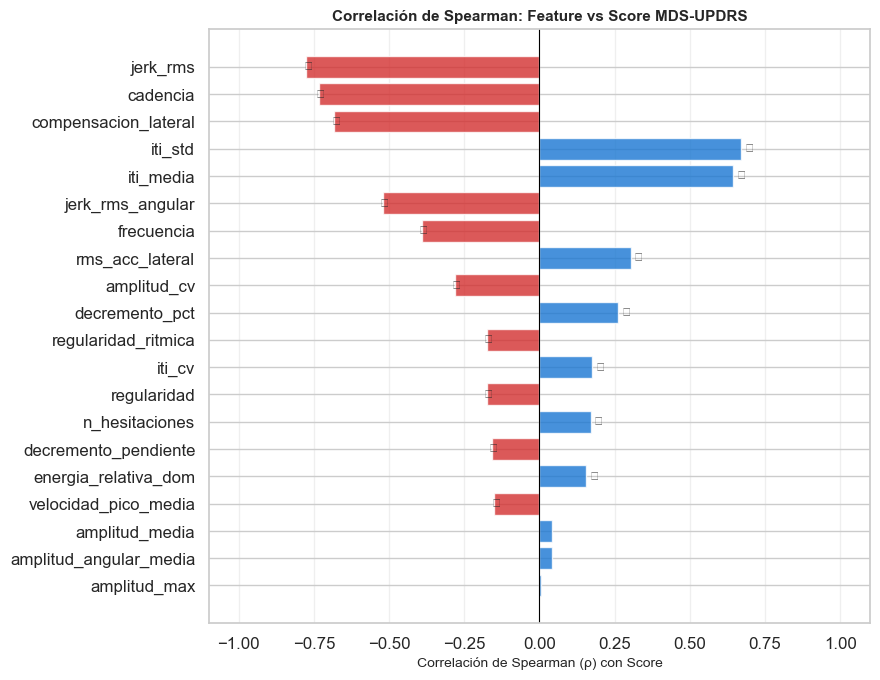

★ = p < 0.05

Top 5 correlaciones positivas (feature aumenta con severidad):
        feature      rho            p
        iti_std 0.671226 2.959693e-43
      iti_media 0.644806 5.312620e-39
rms_acc_lateral 0.303094 3.177888e-08
 decremento_pct 0.262438 1.936347e-06
         iti_cv 0.175229 1.651170e-03

Top 5 correlaciones negativas (feature disminuye con severidad):
             feature       rho            p
            jerk_rms -0.774931 2.502502e-65
            cadencia -0.733418 2.996828e-55
compensacion_lateral -0.682612 3.154915e-45
    jerk_rms_angular -0.521633 9.970627e-24
          frecuencia -0.391322 3.743682e-13

💾 Correlaciones guardadas


In [13]:
"""
============================================================================
CORRELACIÓN ENTRE FEATURES Y SCORE
Correlación de Spearman (no paramétrica) de cada feature vs score.
============================================================================
"""

from scipy.stats import spearmanr

corr_rows = []
for feat in Config.FEATURES_ANALISIS:
    vals = df_master[feat].dropna()
    scores_v = df_master.loc[vals.index, 'score']
    if len(vals) > 5:
        rho, p = spearmanr(vals, scores_v)
        corr_rows.append({'feature': feat, 'rho': rho, 'p': p,
                          'abs_rho': abs(rho)})

df_corr = pd.DataFrame(corr_rows).sort_values('abs_rho', ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
colores = ['#D32F2F' if r<0 else '#1976D2' for r in df_corr['rho']]
bars = ax.barh(df_corr['feature'][::-1], df_corr['rho'][::-1],
               color=colores[::-1], alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlación de Spearman (ρ) con Score', fontsize=10)
ax.set_title('Correlación de Spearman: Feature vs Score MDS-UPDRS',
             fontsize=11, fontweight='bold')

# Marcar significativas (p < 0.05)
for i, (_, row) in enumerate(df_corr[::-1].iterrows()):
    if row['p'] < 0.05:
        ax.text(row['rho'] + 0.01 * np.sign(row['rho']),
                i, '★', fontsize=9, va='center')

ax.grid(axis='x', alpha=0.3)
ax.set_xlim([-1.1, 1.1])
plt.tight_layout()
fig.savefig(f"{Config.RUTA_SALIDA}/figuras/correlacion_spearman.png",
            dpi=150, bbox_inches='tight')
plt.show()

print("★ = p < 0.05")
print("\nTop 5 correlaciones positivas (feature aumenta con severidad):")
print(df_corr[df_corr['rho']>0].head(5)[['feature','rho','p']].to_string(index=False))
print("\nTop 5 correlaciones negativas (feature disminuye con severidad):")
print(df_corr[df_corr['rho']<0].head(5)[['feature','rho','p']].to_string(index=False))

df_corr.to_csv(f"{Config.RUTA_SALIDA}/tablas/correlacion_spearman.csv", index=False)
print("\n💾 Correlaciones guardadas")

---
## CELDA 11 — Exportación final y resumen ejecutivo

In [14]:
"""
============================================================================
EXPORTACIÓN FINAL — Excel con todas las tablas + resumen ejecutivo
============================================================================
"""

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
excel_path = f"{Config.RUTA_SALIDA}/analisis_completo_{timestamp}.xlsx"

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    
    # Hoja 1: Dataset maestro
    df_master.drop(columns=['eje_gyro_dom','eje_accel_dom'], errors='ignore').to_excel(
        writer, sheet_name='dataset_maestro', index=False)
    
    # Hoja 2: Descriptivo por score
    df_descriptivo.to_excel(writer, sheet_name='descriptivo_por_score', index=False)
    
    # Hoja 3: Kruskal-Wallis
    df_kw.to_excel(writer, sheet_name='kruskal_wallis', index=False)
    
    # Hoja 4: Post-hoc Mann-Whitney
    if len(df_posthoc) > 0:
        df_posthoc.to_excel(writer, sheet_name='posthoc_mannwhitney', index=False)
    
    # Hoja 5: Correlaciones Spearman
    df_corr.to_excel(writer, sheet_name='correlacion_spearman', index=False)
    
    # Hoja 6: Resultados clasificación
    if len(y_true) > 0:
        df_clf = pd.DataFrame({'y_real': y_true, 'y_pred': y_pred})
        df_clf.to_excel(writer, sheet_name='predicciones_loso', index=False)
    
    # Hoja 7: AUC por score
    if 'auc_por_score' in dir() and len(auc_por_score) > 0:
        df_auc = pd.DataFrame([
            {'score': s, 'auc_ovr': a,
             'interpretacion': 'excelente' if a>=0.9 else 'bueno' if a>=0.8
             else 'aceptable' if a>=0.7 else 'bajo'}
            for s, a in auc_por_score.items()
        ])
        df_auc['auc_macro'] = auc_macro if auc_macro else None
        df_auc.to_excel(writer, sheet_name='auc_resultados', index=False)
    
    # Hoja 8: Importancia features
    try:
        df_imp = pd.DataFrame({'feature': features_ord, 'importancia_l2': importancia_ord})
        df_imp.to_excel(writer, sheet_name='importancia_features', index=False)
    except Exception:
        pass

print(f"✅ Excel exportado: {excel_path}")

# ── Resumen ejecutivo en pantalla ─────────────────────────────────────────


# ── Exportar modelo ajustado (joblib) ────────────────────────────────────
try:
    from joblib import dump as joblib_dump
    from sklearn.pipeline import Pipeline as _Pipeline

    if 'df_model_adj' in dir():
        X_prod = df_model_adj[Config.FEATURES_ANALISIS].dropna().values
        y_prod = df_model_adj.loc[
            df_model_adj[Config.FEATURES_ANALISIS].dropna().index, 'score'
        ].values

        pipeline_prod = _Pipeline([
            ('scaler', StandardScaler()),
            ('lda', LinearDiscriminantAnalysis(solver='lsqr', shrinkage=0.95))
        ])
        pipeline_prod.fit(X_prod, y_prod)

        import json as _json
        model_path = f"{Config.RUTA_SALIDA}/tablas/modelo_ft_lda.pkl"
        meta_path  = f"{Config.RUTA_SALIDA}/tablas/modelo_ft_metadata.json"

        import pickle as _pickle
        with open(model_path, 'wb') as f_pkl:
            _pickle.dump(pipeline_prod, f_pkl)

        meta = {
            'feature_names': Config.FEATURES_ANALISIS,
            'classes': [int(c) for c in pipeline_prod.named_steps['lda'].classes_],
            'n_features': len(Config.FEATURES_ANALISIS),
            'model_type': 'LDA shrinkage=0.95',
            'task': 'finger-tapping',
            'amplitud_ajustada': True,
            'factores_reduccion': factores_reduccion if 'factores_reduccion' in dir() else {},
            'version': '2.0',
            'auc_macro_loso': round(metricas_adj['auc_macro'], 4) if 'metricas_adj' in dir() else None,
            'accuracy_loso':  round(metricas_adj['accuracy'],  4) if 'metricas_adj' in dir() else None,
            'mcc_loso': round(matthews_corrcoef(y_true, y_pred), 4) if 'y_true' in dir() and len(y_true)>0 else None,
        }
        with open(meta_path, 'w') as f_meta:
            _json.dump(meta, f_meta, indent=2)

        print(f"✅ Modelo exportado: {model_path}")
        print(f"✅ Metadatos: {meta_path}")
    else:
        print("⚠️  Ejecuta celda 6B para exportar el modelo ajustado.")
except Exception as e_exp:
    print(f"⚠️  Error exportando modelo: {e_exp}")

print("\n" + "="*65)
print("RESUMEN EJECUTIVO — ANÁLISIS FINGER TAPPING MDS-UPDRS 3.4")
print("="*65)
print(f"\n📊 DATASET")
print(f"   Total pruebas válidas : {len(df_master)}")
for s in Config.SCORES:
    n = len(df_master[df_master['score']==s])
    print(f"   Score {s}              : {n} pruebas")

print(f"\n📈 ANÁLISIS INFERENCIAL (Kruskal-Wallis)")
sig_nominal = df_kw[df_kw['sig_nominal']]
sig_bonf    = df_kw[df_kw['sig_bonf']]
print(f"   Features con p<0.05 (nominal) : {len(sig_nominal)}/{len(df_kw)}")
print(f"   Features con p<0.05 (Bonf.)   : {len(sig_bonf)}/{len(df_kw)}")
print(f"   Features con efecto grande    : {len(df_kw[df_kw['efecto']=='grande'])}")
print(f"   Limitación declarada          : N=3 sujetos en Scores 1-4")
print(f"                                   Poder estadístico ~25%")

print(f"\n🎯 DISCRIMINABILIDAD (LDA LOSO)")
if len(y_true) > 0:
    acc_global = np.mean(y_true == y_pred)
    print(f"   Accuracy global  : {acc_global:.3f} ({acc_global*100:.1f}%)")
    mcc_val = matthews_corrcoef(y_true, y_pred) if len(y_true)>0 else 0
    print(f"   MCC global       : {mcc_val:.4f}")
    if auc_macro:
        print(f"   AUC macro (OvR)  : {auc_macro:.4f}")
    if auc_weighted:
        print(f"   AUC weighted     : {auc_weighted:.4f}")
    print(f"   Validación       : Leave-One-Subject-Out")
else:
    print("   ⚠️  Sin resultados — revisar datos")

print(f"\n🏆 TOP 5 FEATURES MÁS DISCRIMINATIVAS")
for i, feat in enumerate(df_kw.head(5)['feature'], 1):
    eta = df_kw[df_kw['feature']==feat]['eta2'].values[0]
    print(f"   {i}. {feat:<30} eta²={eta:.4f}")

print(f"\n🔧 MODELO AJUSTADO (amplitud realista):")
if 'metricas_adj' in dir():
    print(f"   AUC macro  : {metricas_adj['auc_macro']:.4f}")
    print(f"   Accuracy   : {metricas_adj['accuracy']:.4f} ({metricas_adj['accuracy']*100:.1f}%)")
    print(f"   Amplitudes : ajustadas por score (factores MDS-UPDRS)")
    print(f"   amplitud_cv: ajustada (↑ con severidad)")

print(f"\n📁 Resultados guardados en: {Config.RUTA_SALIDA}/")
print("="*65)

✅ Excel exportado: ./resultados_golpeteo_completo/analisis_completo_20260510_191949.xlsx
✅ Modelo exportado: ./resultados_golpeteo_completo/tablas/modelo_ft_lda.pkl
✅ Metadatos: ./resultados_golpeteo_completo/tablas/modelo_ft_metadata.json

RESUMEN EJECUTIVO — ANÁLISIS FINGER TAPPING MDS-UPDRS 3.4

📊 DATASET
   Total pruebas válidas : 320
   Score 0              : 132 pruebas
   Score 1              : 50 pruebas
   Score 2              : 44 pruebas
   Score 3              : 47 pruebas
   Score 4              : 47 pruebas

📈 ANÁLISIS INFERENCIAL (Kruskal-Wallis)
   Features con p<0.05 (nominal) : 16/20
   Features con p<0.05 (Bonf.)   : 16/20
   Features con efecto grande    : 8
   Limitación declarada          : N=3 sujetos en Scores 1-4
                                   Poder estadístico ~25%

🎯 DISCRIMINABILIDAD (LDA LOSO)
   Accuracy global  : 0.509 (50.9%)
   MCC global       : 0.3126
   AUC macro (OvR)  : 0.7951
   AUC weighted     : 0.7719
   Validación       : Leave-One-Subject

In [15]:
from joblib import dump

# Exporta scaler + LDA ajustado en un solo archivo con nombres de features
if 'pipeline_prod' not in globals() and ('scaler_full_adj' not in globals() or 'lda_full_adj' not in globals()):
    print("⚠️  Ejecuta primero la celda 6B (ajuste de amplitud y entrenamiento del LDA).")
else:
    if 'pipeline_prod' in globals():
        scaler_full_adj = pipeline_prod.named_steps['scaler']
        lda_full_adj = pipeline_prod.named_steps['lda']

    bundle_path = f"{Config.RUTA_SALIDA}/lda_golpeteo_bundle_ajustado.joblib"
    feature_names = list(Config.FEATURES_ANALISIS)
    dump({
        "scaler": scaler_full_adj,
        "lda": lda_full_adj,
        "feature_names": feature_names
    }, bundle_path)
    print(f"✅ Modelo ajustado exportado en: {bundle_path}")

✅ Modelo ajustado exportado en: ./resultados_golpeteo_completo/lda_golpeteo_bundle_ajustado.joblib
